# Gold 05 — Anomaly Detection Timeline and Alert Review

### Ask

What is this notebook doing?

### Answer

This notebook takes the saved Gold model outputs and turns them into timeline-based anomaly detection review artifacts.

The goal is to move beyond summary metrics and inspect when alerts happen, how much lead time they provide before failure, and how the baseline and cascade outputs behave around important event windows.

This notebook creates:

- selected model timeline data
- detected-row review tables
- failure lead-time summaries
- alert packet summaries
- baseline versus cascade comparison outputs
- timeline plots
- all-sensor heatmaps and surface plots
- packet-centered review plots
- final anomaly-detection exports and truth metadata

## Imports

### Ask

Why does Gold 05 need its own imports?

### Answer

Gold 05 is mostly an analysis and visualization notebook, so it needs plotting, dataframe, artifact, configuration, and lineage utilities.

It does not train a new model. Instead, it loads model result artifacts that were already created and turns them into timeline review outputs.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Sequence, Any, Dict, Mapping, Final, Literal, cast

import os
import json
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure


from mpl_toolkits.mplot3d.axes3d import Axes3D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.axes3d import Axes3D

from matplotlib.ticker import MaxNLocator


from utils.core.paths import get_paths
from utils.core.logging_setup import configure_logging, log_layer_paths
from utils.core.ledger import Ledger
from utils.core.file_io import (
    load_data, 
    save_data, 
    save_json,
)

from utils.core.config_loader import (
    load_pipeline_config,
    build_truth_config_block,
    set_wandb_dir_from_config,
    export_config_snapshot,
)

from utils.core.truths import (
    identify_meta_columns,
    identify_feature_columns,
    extract_truth_hash,
    initialize_layer_truth,
    update_truth_section,
    build_truth_record,
    save_truth_record,
    append_truth_index,
    stamp_truth_columns,
    make_process_run_id,
)

# optional existing helper module if you already saved it into utils or notebook path
try:
    from utils.medallion.gold.cascade_row_tracking import get_stage_detected_rows_dataframe
except Exception:
    get_stage_detected_rows_dataframe = None

from utils.database.postgres import (
    get_engine_from_env, 
    read_sql_dataframe,
)
from utils.database.layer_postgres import (
    read_layer_dataframe, 
    write_layer_dataframe, 
    prepare_layer_dataframe,
)

from utils.database.sql_notebook_helpers import (
    delete_dataset_run_rows,
    execute_many,
    get_existing_dataframe,
    get_row_value,
    log_data_quality_event,
    log_pipeline_artifact,
    preview_sql_table,
    row_to_payload,
    sql_table_ref,
    to_builtin,
    to_json_string,
    to_scalar,
    upsert_pipeline_run,
)

from utils.database.medallion_sql_writers import (
    log_gold_05_anomaly_detection_summary_sql,
    log_silver_eda_sql,
    write_bronze_sensor_observations_sql,
    write_gold_baseline_scores_sql,
    write_gold_cascade_scores_sql,
    write_gold_model_comparison_results_sql,
    write_gold_preprocessed_features_sql,
    write_silver_sensor_observation_features_sql,
)

from utils.core.artifacts import (
    build_artifact_dirs,
    build_artifact_dirs_from_config,
    artifact_file_path,
)

from utils.core.notebook_context import load_notebook_context

# Show more columns
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)


----

In [2]:
# --------------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------------

def require_int_value(value: int | None, name: str) -> int:
    """
    Validate that a nullable integer value is present before converting it.
    """
    if value is None:
        raise ValueError(f"{name} could not be resolved and is None.")

    return int(value)


def cfg_require_mapping(value: object, name: str) -> Mapping[str, Any]:
    if not isinstance(value, Mapping):
        raise TypeError(
            f"{name} must be a mapping, got {type(value).__name__}: {value!r}"
        )

    return cast(Mapping[str, Any], value)


def cfg_optional_mapping(value: object | None, name: str) -> Mapping[str, Any]:
    if value is None:
        return {}

    return cfg_require_mapping(value, name)


----

## Paths, Configuration, Logger, and Ledger

### Ask

What project setup happens here?

### Answer

This cell resolves the project paths, loads the Gold 05 configuration, starts logging, and initializes the anomaly-detection ledger.

That gives the notebook a consistent place to write exports, plots, summaries, and the final ledger record.

In [ ]:
# Shared notebook context
CONTEXT_STAGE = "gold_anomaly_detection"
CONTEXT_DATASET = "pump"
CONTEXT_LAYER = "gold"
CONFIG_RUN_MODE = "train"
CONFIG_PROFILE = "default"
CONTEXT_LOG_FILE = "gold_anomaly_detection.log"

CTX = load_notebook_context(
    stage=CONTEXT_STAGE,
    dataset=CONTEXT_DATASET,
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    logger_child_name="capstone.gold.anomaly_detection",
    log_filename=CONTEXT_LOG_FILE,
)

# Shared aliases used throughout the notebook
paths = CTX.paths
CONFIG = CTX.config
CONFIG_MAP = CTX.config
STAGE_CFG = CTX.stage_config
ANOMALY_DETECTION_CFG = CTX.stage_config
RESOLVED_PATHS = CTX.resolved_paths
FILENAMES = CTX.filenames
VERSIONS_CFG = CTX.versions
RUNTIME_CFG = CTX.runtime
DATASET_CFG = CTX.dataset_config
WANDB_CFG = CTX.wandb
EXECUTION_CFG = CTX.execution
PIPELINE = CTX.pipeline
logger = CTX.logger
ledger = CTX.ledger
LOG_PATH = CTX.log_path
CONTEXT_RECIPE_ID = CTX.recipe_id

logger.info(
    "Notebook context loaded",
    extra={
        "stage": CONTEXT_STAGE,
        "recipe_id": CONTEXT_RECIPE_ID,
        "dataset": CONTEXT_DATASET,
        "mode": CONFIG_RUN_MODE,
        "profile": CONFIG_PROFILE,
    },
)

ledger.add(
    kind="step",
    step="context_loaded",
    message="Loaded shared notebook context.",
    data={
        "stage": CONTEXT_STAGE,
        "recipe_id": CONTEXT_RECIPE_ID,
        "dataset": CONTEXT_DATASET,
        "mode": CONFIG_RUN_MODE,
        "profile": CONFIG_PROFILE,
        "log_path": str(LOG_PATH),
    },
    logger=logger,
)


In [ ]:


TRUTH_CONFIG = cast(Dict[str, Any], build_truth_config_block(CONFIG))
TRUTH_CONFIG["pipeline"] = PIPELINE
TRUTH_CONFIG["stage_params"] = ANOMALY_DETECTION_CFG

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####
# ---- Stage details ----

STAGE = "gold"

LAYER_NAME = str(ANOMALY_DETECTION_CFG["layer_name"])

GOLD_VERSION = str(VERSIONS_CFG["gold"])
TRUTH_VERSION = str(VERSIONS_CFG["truth"])

RECIPE_ID = str(ANOMALY_DETECTION_CFG["recipe_id"])

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####

PIPELINE_MODE = str(PIPELINE["execution_mode"])
RUN_MODE = str(RUNTIME_CFG.get("mode", CONFIG_RUN_MODE))
CONFIG_PROFILE = str(RUNTIME_CFG.get("profile", CONFIG_PROFILE))

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####

DATASET_NAME_CONFIG = str(DATASET_CFG.get("name", "pump"))
DATASET_NAME = DATASET_NAME_CONFIG.strip().lower()

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####

GOLD_PROCESS_RUN_ID = make_process_run_id(
    str(
        ANOMALY_DETECTION_CFG.get(
            "process_run_id_prefix",
            "gold05_anomaly_detection",
        )
    )
)

# Backward-compatible alias for downstream cells.
PROCESS_RUN_ID = GOLD_PROCESS_RUN_ID

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####
# ---- W&B ----

WANDB_PROJECT = str(WANDB_CFG.get("project", "capstone"))
WANDB_ENTITY = str(WANDB_CFG.get("entity", ""))
WANDB_RUN_NAME = f"{GOLD_VERSION}"

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####
# ---- File names ----

GOLD_ANOMALY_DETECTION_LEDGER_FILE_NAME = str(
    FILENAMES.get(
        "gold_anomaly_detection_ledger_file_name",
        "gold_anomaly_detection_ledger.jsonl",
    )
)

MODEL_COMPARISON_FILE_NAME = str(
    FILENAMES.get("model_comparison_file_name", "model_comparison.csv")
)

MODEL_COMPARISON_SUMMARY_FILE_NAME = str(
    FILENAMES.get(
        "model_comparison_summary_file_name",
        "model_comparison_summary.json",
    )
)

COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME = str(
    FILENAMES.get(
        "comparison_plot_with_test_alerts_file_name",
        "comparison_plot_with_test_alerts.png",
    )
)

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####
# ---- Base paths only ----

ARTIFACTS_ROOT = Path(str(RESOLVED_PATHS["artifacts_root"]))

GOLD_ARTIFACTS_PATH = Path(
    str(RESOLVED_PATHS.get("gold_artifacts_dir", ARTIFACTS_ROOT / "gold"))
)

MODEL_COMPARISON_PATH = Path(
    str(
        RESOLVED_PATHS.get(
            "model_comparison_path",
            GOLD_ARTIFACTS_PATH / MODEL_COMPARISON_FILE_NAME,
        )
    )
)

MODEL_COMPARISON_SUMMARY_PATH = Path(
    str(
        RESOLVED_PATHS.get(
            "model_comparison_summary_path",
            GOLD_ARTIFACTS_PATH / MODEL_COMPARISON_SUMMARY_FILE_NAME,
        )
    )
)

COMPARISON_PLOT_WITH_TEST_ALERTS_PATH = Path(
    str(
        RESOLVED_PATHS.get(
            "comparison_plot_with_test_alerts_path",
            GOLD_ARTIFACTS_PATH / COMPARISON_PLOT_WITH_TEST_ALERTS_FILE_NAME,
        )
    )
)

TRUTHS_PATH = Path(str(RESOLVED_PATHS["truths_dir"]))
TRUTH_INDEX_PATH = Path(str(RESOLVED_PATHS["truth_index_path"]))

LOGS_PATH = Path(str(RESOLVED_PATHS["logs_root"]))

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####
# W&B

set_wandb_dir_from_config(CONFIG)

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####
# Path failsafes

ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)
GOLD_ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

MODEL_COMPARISON_PATH.parent.mkdir(parents=True, exist_ok=True)
MODEL_COMPARISON_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
COMPARISON_PLOT_WITH_TEST_ALERTS_PATH.parent.mkdir(parents=True, exist_ok=True)

TRUTHS_PATH.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)

#### #### #### #### #### #### #### #### #### #### #### #### #### #### #### ####

print("Project root:", paths.root)
print("Artifacts root:", ARTIFACTS_ROOT)
print("CONFIG dataset:", DATASET_NAME_CONFIG)
print("Gold artifacts path:", GOLD_ARTIFACTS_PATH)
print("Model comparison path:", MODEL_COMPARISON_PATH)
print("Model comparison summary path:", MODEL_COMPARISON_SUMMARY_PATH)
print("Comparison plot path:", COMPARISON_PLOT_WITH_TEST_ALERTS_PATH)

Project root: /workspace
Artifacts root: /workspace/artifacts
CONFIG dataset: pump
Gold artifacts path: /workspace/artifacts/gold/pump
Model comparison path: /workspace/artifacts/gold/pump/comparison/results/pump__gold__model_comparison.csv
Model comparison summary path: /workspace/artifacts/gold/pump/comparison/summaries/pump__gold__model_comparison_summary.json
Comparison plot path: /workspace/artifacts/gold/pump/comparison/plots/pump__gold__comparison__2panel_test_alerts_and_metrics.png


----

## Configurables


In [4]:


SELECTED_RUN_KEY = "stage3_improved"
# valid:
#   baseline
#   cascade_defaults
#   cascade_tuned
#   stage3_improved

USE_GLOBAL_RESULTS_IF_AVAILABLE = True

RECOVERY_STABILITY_ROWS = 30
RECOVERY_STARTS_AFTER_BROKEN = True

ROW_ID_COLUMN = "meta__row_id"
TIME_AXIS_CANDIDATES = ["time_index", "event_step", "event_time"]
STATUS_COLUMN_CANDIDATES = ["machine_status", "status", "state"]

DEFAULT_SENSOR_FOR_TIMELINE = "sensor_00"
PLOT_WINDOW_BEFORE_CENTER = 300
PLOT_WINDOW_AFTER_CENTER = 300
PLOT_ALERT_MARKER_SIZE = 18
ALERT_PACKET_MAX_GAP_ROWS = 5


PLOT_SENSOR_NORMALIZATION_METHOD = "robust_zscore"
PLOT_SENSOR_CLIP_VALUE = 5.0
PLOT_GRID_ALPHA = 0.25
PLOT_EVENT_ALPHA = 0.85
PLOT_ALERT_SPAN_ALPHA = 0.08

PLOT_RUN_LABEL_MAP = {
    "baseline": "Baseline Isolation Forest",
    "cascade_defaults": "Cascade Defaults",
    "cascade_tuned": "Cascade Tuned",
    "stage3_improved": "Stage 3 Improved",
    "stage3_medium": "Stage 3 Medium",
    "stage3_strict": "Stage 3 Strict",
}

RUN_CONFIG_MAP = {
    "baseline": {
        "target_flag_column": "baseline_flag",
        "primary_score_column": "baseline_score",
        "primary_decision_column": "baseline_decision",
        "run_family": "baseline",
    },
    "cascade_defaults": {
        "target_flag_column": "cascade_final_flag",
        "primary_score_column": "stage2_score",
        "primary_decision_column": "stage2_model_decision",
        "run_family": "cascade",
    },
    "cascade_tuned": {
        "target_flag_column": "cascade_final_flag",
        "primary_score_column": "stage2_score",
        "primary_decision_column": "stage2_model_decision",
        "run_family": "cascade",
    },
    "stage3_improved": {
        "target_flag_column": "cascade_final_flag",
        "primary_score_column": "stage2_score",
        "primary_decision_column": "stage2_model_decision",
        "run_family": "cascade",
    },
    "stage3_medium": {
        "target_flag_column": "cascade_stage3_medium_flag",
        "primary_score_column": "stage3_weighted_score",
        "primary_decision_column": "stage3_priority_class",
        "run_family": "cascade",
    },
    "stage3_strict": {
        "target_flag_column": "cascade_stage3_strict_flag",
        "primary_score_column": "stage3_weighted_score",
        "primary_decision_column": "stage3_priority_class",
        "run_family": "cascade",
    },
}

if SELECTED_RUN_KEY not in RUN_CONFIG_MAP:
    raise ValueError(
        f"Unsupported SELECTED_RUN_KEY: {SELECTED_RUN_KEY}. "
        f"Valid keys: {list(RUN_CONFIG_MAP)}"
    )

PLOT_RUN_LABEL = PLOT_RUN_LABEL_MAP.get(SELECTED_RUN_KEY, SELECTED_RUN_KEY)
SELECTED_RUN_CONFIG = RUN_CONFIG_MAP[SELECTED_RUN_KEY]

TARGET_FLAG_COLUMN = SELECTED_RUN_CONFIG["target_flag_column"]
PRIMARY_SCORE_COLUMN = SELECTED_RUN_CONFIG["primary_score_column"]
PRIMARY_DECISION_COLUMN = SELECTED_RUN_CONFIG["primary_decision_column"]
RUN_FAMILY = SELECTED_RUN_CONFIG["run_family"]


----

In [5]:
# =============================================================================
# SQL Runtime Context
# Purpose:
#   Establish the Postgres connection and resolve the dataset/run identifiers
#   used by SQL logging and medallion table writes.
# =============================================================================

engine = get_engine_from_env()

CAPSTONE_SCHEMA: str = str(os.getenv("CAPSTONE_SCHEMA", "capstone"))


def first_non_empty_string(*values: object) -> str | None:
    """
    Return the first non-empty string-like value from a list of candidates.

    This helper skips None, empty strings, whitespace-only strings, and
    dictionaries. It is used to resolve dataset/run identifiers without
    accidentally accepting an invalid config object or a placeholder None value.
    """
    for value in values:
        if value is None:
            continue

        if isinstance(value, dict):
            continue

        text_value = str(value).strip()

        if text_value:
            return text_value

    return None


dataset_config = (
    cast(Dict[str, Any], CONFIG.get("dataset", {}))
    if isinstance(CONFIG.get("dataset", {}), dict)
    else {}
)

dataset_config_name = dataset_config.get("name")
dataset_config_id = dataset_config.get("dataset_id", dataset_config.get("id"))
dataset_config_run_id = dataset_config.get("run_id")
dataset_config_asset_id = dataset_config.get("asset_id")

is_synthetic_run = str(RUN_MODE).lower() in {
    "synthetic",
    "synthetic_train",
    "synthetic_run",
    "simulation",
}

if is_synthetic_run:
    raw_dataset_id = first_non_empty_string(
        os.getenv("CAPSTONE_DATASET_ID"),
        os.getenv("SYNTHETIC_DATASET_ID"),
        globals().get("DATASET_ID"),
        dataset_config_id,
        globals().get("DATASET_NAME_CONFIG"),
        dataset_config_name,
        "pump_synthetic_v1",
    )

    raw_run_id = first_non_empty_string(
        os.getenv("CAPSTONE_RUN_ID"),
        os.getenv("SYNTHETIC_RUN_ID"),
        globals().get("DATASET_RUN_ID"),
        dataset_config_run_id,
        globals().get("RUN_ID"),
        globals().get("RUN_ID_DEFAULT_FALLBACK"),
        "synthetic_run_001",
    )

    raw_asset_id = first_non_empty_string(
        os.getenv("CAPSTONE_ASSET_ID"),
        os.getenv("SYNTHETIC_ASSET_ID"),
        globals().get("ASSET_ID"),
        dataset_config_asset_id,
        globals().get("ASSET_ID_DEFAULT_FALLBACK"),
        "pump_asset_001",
    )

else:
    raw_dataset_id = first_non_empty_string(
        os.getenv("CAPSTONE_DATASET_ID"),
        globals().get("DATASET_ID"),
        dataset_config_id,
        globals().get("DATASET_NAME_CONFIG"),
        dataset_config_name,
        "pump",
    )

    raw_run_id = first_non_empty_string(
        os.getenv("CAPSTONE_RUN_ID"),
        globals().get("DATASET_RUN_ID"),
        dataset_config_run_id,
        globals().get("RUN_ID"),
        globals().get("RUN_ID_DEFAULT_FALLBACK"),
        "run__001",
    )

    raw_asset_id = first_non_empty_string(
        os.getenv("CAPSTONE_ASSET_ID"),
        globals().get("ASSET_ID"),
        dataset_config_asset_id,
        globals().get("ASSET_ID_DEFAULT_FALLBACK"),
        "asset__001",
    )


if raw_dataset_id is None:
    raise ValueError(
        "DATASET_ID could not be resolved. "
        "Set CAPSTONE_DATASET_ID or configure CONFIG['dataset']['name'] / "
        "CONFIG['dataset']['dataset_id']."
    )

if raw_run_id is None:
    raise ValueError(
        "RUN_ID could not be resolved. "
        "Set CAPSTONE_RUN_ID, CONFIG['dataset']['run_id'], or default_fallbacks.run_id."
    )

if raw_asset_id is None:
    raise ValueError(
        "ASSET_ID could not be resolved. "
        "Set CAPSTONE_ASSET_ID, CONFIG['dataset']['asset_id'], or default_fallbacks.asset_id."
    )


DATASET_ID: str = raw_dataset_id
RUN_ID: str = raw_run_id
ASSET_ID: str = raw_asset_id


print(f"SQL schema: {CAPSTONE_SCHEMA}")
print(f"Dataset ID: {DATASET_ID}")
print(f"Run ID: {RUN_ID}")
print(f"Asset ID: {ASSET_ID}")
print(f"Synthetic run: {is_synthetic_run}")

SQL schema: capstone
Dataset ID: pump
Run ID: run__001
Asset ID: asset__001
Synthetic run: False


#### Review intermediate output

This cell displays an intermediate checkpoint. Use the output to confirm that the expected rows, columns, dtypes, or summary values are present before continuing.

In [6]:

# =============================================================================
# SQL Smoke Check
# Purpose:
#   Confirm the database connection and expected capstone schemas/tables exist.
# =============================================================================

sql_smoke_check_dataframe = read_sql_dataframe(
    engine,
    """
    SELECT
        table_schema,
        table_name
    FROM information_schema.tables
    WHERE table_schema IN (:capstone_schema, 'bronze', 'silver', 'gold', 'metadata')
    ORDER BY table_schema, table_name
    """,
    params={"capstone_schema": CAPSTONE_SCHEMA},
)

display(sql_smoke_check_dataframe)

,table_schema,table_name
0,bronze,sensor_observations
1,capstone,bronze_observations_input_stage
2,capstone,data_quality_events
3,capstone,pipeline_artifacts
4,capstone,pipeline_runs
5,capstone,simulation_state_control
6,capstone,simulation_timing_config
7,capstone,synthetic_observations_premelt_stage
8,capstone,synthetic_observations_timestamped_stage
9,capstone,synthetic_pump_stream


---

## Start Logging for the Anomaly Detection Stage


In [ ]:
log_layer_paths(paths, current_layer=CONTEXT_LAYER, logger=logger)

logger.info(
    "Project paths logged for %s layer",
    CONTEXT_LAYER,
    extra={"stage": CONTEXT_STAGE, "layer": CONTEXT_LAYER},
)

ledger.add(
    kind="step",
    step=f"{CONTEXT_LAYER}_paths_logged",
    message="Logged project layer paths.",
    data={
        "stage": CONTEXT_STAGE,
        "layer": CONTEXT_LAYER,
        "log_path": str(LOG_PATH),
    },
    logger=logger,
)


In [ ]:
""" 
# Original Logging Setup

# Create gold log path 
gold_log_path = paths.logs / "gold_anomaly_detection.log"

# Initial Logger
configure_logging(
    "capstone",
    gold_log_path,
    level=logging.DEBUG,
    overwrite_handlers=True,
)

# Initiate Logger and log file
logger = logging.getLogger("capstone.gold.anomaly_detection")

# Log load and initiation
logger.info("Gold Modeling stage starting")

# Log paths loads
log_layer_paths(paths, current_layer="gold", logger=logger)
 """

2026-06-09 06:56:34,262 | INFO | capstone.gold.anomaly_detection | Gold Modeling stage starting
2026-06-09 06:56:34,264 | INFO | capstone.gold.anomaly_detection | Project Root Path Loaded: /workspace
2026-06-09 06:56:34,265 | INFO | capstone.gold.anomaly_detection | Project Logging Path Loaded: /workspace/logs
2026-06-09 06:56:34,268 | INFO | capstone.gold.anomaly_detection | Project Artifacts Path Loaded: /workspace/artifacts
2026-06-09 06:56:34,270 | INFO | capstone.gold.anomaly_detection | Project Notebooks Path Loaded: /workspace/notebooks
2026-06-09 06:56:34,272 | INFO | capstone.gold.anomaly_detection | Project Truths Path Loaded: /workspace/artifacts/truths
2026-06-09 06:56:34,275 | INFO | capstone.gold.anomaly_detection | Project Data Path Loaded: /workspace/data
2026-06-09 06:56:34,277 | INFO | capstone.gold.anomaly_detection | Previous Layer (Silver) Path Loaded: /workspace/data/silver
2026-06-09 06:56:34,280 | INFO | capstone.gold.anomaly_detection | Previous Layer (Silver) 

---

## Initialize the Anomaly Detection Ledger

Here I create the ledger that tracks the main steps taken during the anomaly detection notebook.


In [ ]:
# Ledger was initialized by load_notebook_context().
# Keep this cell as a visible notebook checkpoint instead of re-creating Ledger.

ledger.add(
    kind="step",
    step="ledger_context_ready",
    message="Ledger is available from shared notebook context.",
    data={
        "stage": CONTEXT_STAGE,
        "recipe_id": CONTEXT_RECIPE_ID,
        "log_path": str(LOG_PATH),
    },
    logger=logger,
)

logger.info(
    "Ledger ready from notebook context",
    extra={"stage": CONTEXT_STAGE, "recipe_id": CONTEXT_RECIPE_ID},
)


In [ ]:
""" 
# Original Ledger Setup

ledger = Ledger(
    stage=STAGE, 
    recipe_id=PROCESS_RUN_ID)

ledger.add(
    kind="step",
    step="init",
    message="Initialized ledger",
    logger=logger
)


ledger.add(
    kind="decision",
    step="notebook_init",
    message="Initialized Gold 05 anomaly detection notebook with utils-based paths/config/logging.",
    why="Gold 05 should align with the rest of the capstone project architecture.",
    consequence="Result loading, exports, logs, and truths will follow project-standard utilities.",
    data={
        "dataset_name": DATASET_NAME,
        "stage": STAGE,
        "pipeline_mode": PIPELINE_MODE,
        "process_run_id": PROCESS_RUN_ID,
        "selected_run_key": SELECTED_RUN_KEY,
    },
    logger=logger,
) """

2026-06-09 06:56:34,301 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:56:34.301079+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger', 'why': None, 'consequence': None, 'data': {}}
2026-06-09 06:56:34,306 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:56:34.306399+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'decision', 'step': 'notebook_init', 'message': 'Initialized Gold 05 anomaly detection notebook with utils-based paths/config/logging.', 'why': 'Gold 05 should align with the rest of the capstone project architecture.', 'consequence': 'Result loading, exports, logs, and truths will follow project-standard utilities.', 'data': {'dataset_name': 'pump', 'stage': 'gold', 'pipeline_mode': 'batch', 'process_run_id': 'gold_anomaly_detection__20260609T065634Z', 'selected_run_key': 'stage3_improve

{'ts_utc': '2026-06-09T06:56:34.306399+00:00',
 'stage': 'gold',
 'recipe': 'gold_anomaly_detection__20260609T065634Z',
 'kind': 'decision',
 'step': 'notebook_init',
 'message': 'Initialized Gold 05 anomaly detection notebook with utils-based paths/config/logging.',
 'why': 'Gold 05 should align with the rest of the capstone project architecture.',
 'consequence': 'Result loading, exports, logs, and truths will follow project-standard utilities.',
 'data': {'dataset_name': 'pump',
  'stage': 'gold',
  'pipeline_mode': 'batch',
  'process_run_id': 'gold_anomaly_detection__20260609T065634Z',
  'selected_run_key': 'stage3_improved'}}

---

## Resolve Model Result Paths

### Ask

Why map result paths by run key?

### Answer

Gold 05 can review multiple saved model outputs, including the baseline, default cascade, tuned cascade, and Stage 3 improved cascade.

This path map lets the notebook load a selected run by name instead of hard-coding one result file throughout the notebook.

In [9]:
# =========================================================
# Gold 05 artifact directories
# =========================================================
# Gold 05 reads scored outputs from Gold 02 / 03A / 03B / 03C
# and writes its own anomaly-detection outputs.
#
# The Gold 05 CONFIG owns gold_anomaly_detection, but it may not contain
# the other Gold notebook stage keys. Therefore:
#   - prior Gold model output directories are built directly
#   - Gold 05's own output directory is built from CONFIG

raw_resolved_paths = CONFIG.get("resolved_paths", {})

if not isinstance(raw_resolved_paths, dict):
    raise TypeError(
        "CONFIG['resolved_paths'] must be a dictionary. "
        f"Got {type(raw_resolved_paths).__name__}: {raw_resolved_paths!r}"
    )

raw_artifacts_root = raw_resolved_paths.get("artifacts_root")

if raw_artifacts_root is None:
    raise KeyError(
        "Could not resolve artifacts root. "
        "Expected CONFIG['resolved_paths']['artifacts_root']."
    )

ARTIFACTS_ROOT = Path(raw_artifacts_root)

GOLD_MODEL_SUBDIRS = [
    "scores",
    "summaries",
    "thresholds",
    "metadata",
    "models",
    "plots",
    "config",
    "lineage",
]

GOLD_BASELINE_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="baseline",
    subdirs=GOLD_MODEL_SUBDIRS,
)

GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="cascade_defaults",
    subdirs=GOLD_MODEL_SUBDIRS,
)

GOLD_CASCADE_TUNED_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="cascade_tuned",
    subdirs=GOLD_MODEL_SUBDIRS,
)

GOLD_CASCADE_STAGE3_ARTIFACT_DIRS = build_artifact_dirs(
    artifacts_root=ARTIFACTS_ROOT,
    stage="gold",
    dataset_name=DATASET_NAME,
    family="cascade_stage3_improved",
    subdirs=GOLD_MODEL_SUBDIRS,
)

ANOMALY_DETECTION_ARTIFACT_DIRS = build_artifact_dirs_from_config(
    config=CONFIG,
    stage_key="gold_anomaly_detection",
)

ANOMALY_DETECTION_ARTIFACT_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["root"]
ANOMALY_DETECTION_EXPORT_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["exports"]
ANOMALY_DETECTION_PLOT_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["plots"]
ANOMALY_DETECTION_SUMMARY_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["summaries"]
ANOMALY_DETECTION_PACKET_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["packets"]
ANOMALY_DETECTION_METADATA_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["metadata"]
ANOMALY_DETECTION_CONFIG_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["config"]
ANOMALY_DETECTION_LINEAGE_DIR = ANOMALY_DETECTION_ARTIFACT_DIRS["lineage"]

CONFIG_SNAPSHOT_PATH = (
    ANOMALY_DETECTION_CONFIG_DIR
    / f"{DATASET_NAME}__gold_anomaly_detection__resolved_config.yaml"
)

if CONFIG["execution"].get("save_config_snapshot", True):
    export_config_snapshot(CONFIG, CONFIG_SNAPSHOT_PATH)

RUN_RESULT_PATH_MAP = {
    "baseline": (
        GOLD_BASELINE_ARTIFACT_DIRS["scores"]
        / FILENAMES["baseline_results_file_name_pickle"]
    ),
    "cascade_defaults": (
        GOLD_CASCADE_DEFAULTS_ARTIFACT_DIRS["scores"]
        / FILENAMES["cascade_defaults_results_file_name_pickle"]
    ),
    "cascade_tuned": (
        GOLD_CASCADE_TUNED_ARTIFACT_DIRS["scores"]
        / FILENAMES["cascade_tuned_results_file_name_pickle"]
    ),
    "stage3_improved": (
        GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["scores"]
        / FILENAMES["cascade_stage3_improved_results_file_name_pickle"]
    ),
    "stage3_medium": (
        GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["scores"]
        / FILENAMES["cascade_stage3_improved_results_file_name_pickle"]
    ),
    "stage3_strict": (
        GOLD_CASCADE_STAGE3_ARTIFACT_DIRS["scores"]
        / FILENAMES["cascade_stage3_improved_results_file_name_pickle"]
    ),
}

GOLD05_LEDGER_PATH = (
    ANOMALY_DETECTION_LINEAGE_DIR
    / FILENAMES.get(
        "gold_anomaly_detection_ledger_file_name",
        f"ledger__{DATASET_NAME}__gold_anomaly_detection.json",
    )
)

logger.info("Selected run artifact path: %s", RUN_RESULT_PATH_MAP[SELECTED_RUN_KEY])

ledger.add(
    kind="decision",
    step="resolved_run_paths",
    message="Resolved selected run artifact path from pipeline config.",
    why="Gold 05 should load scored outputs from config-derived artifact paths by default.",
    consequence="Notebook can run standalone after kernel reset.",
    data={
        "selected_run_key": SELECTED_RUN_KEY,
        "selected_run_path": str(RUN_RESULT_PATH_MAP[SELECTED_RUN_KEY]),
    },
    logger=logger,
)

2026-06-09 06:56:35,030 | INFO | capstone.gold.anomaly_detection | Selected run artifact path: /workspace/artifacts/gold/pump/cascade_stage3_improved/scores/pump__gold__cascade_stage3_improved_results.pkl
2026-06-09 06:56:35,032 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:56:35.032008+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'decision', 'step': 'resolved_run_paths', 'message': 'Resolved selected run artifact path from pipeline config.', 'why': 'Gold 05 should load scored outputs from config-derived artifact paths by default.', 'consequence': 'Notebook can run standalone after kernel reset.', 'data': {'selected_run_key': 'stage3_improved', 'selected_run_path': '/workspace/artifacts/gold/pump/cascade_stage3_improved/scores/pump__gold__cascade_stage3_improved_results.pkl'}}


{'ts_utc': '2026-06-09T06:56:35.032008+00:00',
 'stage': 'gold',
 'recipe': 'gold_anomaly_detection__20260609T065634Z',
 'kind': 'decision',
 'step': 'resolved_run_paths',
 'message': 'Resolved selected run artifact path from pipeline config.',
 'why': 'Gold 05 should load scored outputs from config-derived artifact paths by default.',
 'consequence': 'Notebook can run standalone after kernel reset.',
 'data': {'selected_run_key': 'stage3_improved',
  'selected_run_path': '/workspace/artifacts/gold/pump/cascade_stage3_improved/scores/pump__gold__cascade_stage3_improved_results.pkl'}}

## Selected Results Loader

### Ask

What does this loader do?

### Answer

This helper loads the saved result dataframe for the selected model run.

The loader gives the notebook one consistent entry point for pulling in baseline or cascade outputs. That makes later timeline-building logic reusable across model variants.

In [10]:
def load_selected_results_from_utils(
    *,
    selected_run_key: str,
    use_globals_if_available: bool = True,
) -> pd.DataFrame:
    """
    Load the selected scored dataframe using:
    1. globals fallback when explicitly allowed
    2. artifact path from config via utils.file_io / pickle

    This version uses globals().get(...) so Pylance does not complain
    about possibly undefined notebook variables.
    """
    if use_globals_if_available:
        primary_global_name_map = {
            "baseline": "baseline_results",
            "cascade_defaults": "cascade_results",
            "cascade_tuned": "cascade_tuned_results",
            "stage3_improved": "stage3_improved_results",
            "stage3_medium": "stage3_improved_results",
            "stage3_strict": "stage3_improved_results",
        }

        primary_global_name = primary_global_name_map.get(selected_run_key)
        primary_global_object = (
            globals().get(primary_global_name)
            if primary_global_name is not None
            else None
        )

        if isinstance(primary_global_object, pd.DataFrame):
            logger.info(
                "Using in-memory %s from globals.",
                primary_global_name,
            )
            return primary_global_object.copy()

        # Fallback for cascade notebooks that only left cascade_results in memory.
        if selected_run_key in {
            "cascade_defaults",
            "cascade_tuned",
            "stage3_improved",
            "stage3_medium",
            "stage3_strict",
        }:
            cascade_results_object = globals().get("cascade_results")

            if isinstance(cascade_results_object, pd.DataFrame):
                logger.info(
                    "Using in-memory cascade_results from globals as fallback for %s.",
                    selected_run_key,
                )
                return cascade_results_object.copy()

    result_path = Path(RUN_RESULT_PATH_MAP[selected_run_key])

    if not result_path.exists():
        raise FileNotFoundError(
            f"Selected run artifact path does not exist: {result_path}"
        )

    logger.info("Loading selected results from artifact path: %s", result_path)

    if result_path.suffix.lower() in {".pkl", ".pickle"}:
        dataframe = pd.read_pickle(result_path)
    else:
        dataframe = load_data(result_path)

    return dataframe.copy()



#### Load selected model results for Gold 05

This cell loads the required input for this stage and applies the configured dataset/run filters. This is the handoff point where `Gold 05` begins working from the prior layer output.

In [11]:

selected_results = load_selected_results_from_utils(
    selected_run_key=SELECTED_RUN_KEY,
    use_globals_if_available=USE_GLOBAL_RESULTS_IF_AVAILABLE,
)

ledger.add(
    kind="step",
    step="load_selected_results",
    message="Loaded selected scored dataframe for Gold 05 anomaly validation.",
    why="Timeline validation operates on a single scored run at a time.",
    consequence="All downstream summaries and plots will use the selected run output.",
    data={
        "selected_run_key": SELECTED_RUN_KEY,
        "row_count": int(len(selected_results)),
        "column_count": int(selected_results.shape[1]),
    },
    logger=logger,
)

display(selected_results.head(4))

2026-06-09 06:56:35,109 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/cascade_stage3_improved/scores/pump__gold__cascade_stage3_improved_results.pkl
2026-06-09 06:56:40,177 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:56:40.177438+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'load_selected_results', 'message': 'Loaded selected scored dataframe for Gold 05 anomaly validation.', 'why': 'Timeline validation operates on a single scored run at a time.', 'consequence': 'All downstream summaries and plots will use the selected run output.', 'data': {'selected_run_key': 'stage3_improved', 'row_count': 220320, 'column_count': 374}}


,meta__asset_id,meta__dataset,meta__episode_id,meta__event_id,meta__ingested_at_utc,meta__parent_truth_hash,meta__pipeline_mode,meta__record_id,meta__run_id,meta__source_file,meta__source_row_id,meta__split,meta__truth_hash,event_time,event_step,time_index,event_date,anomaly_flag,is_anomaly,is_normal,status_normal_value,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,...,sensor_51__value_deviation,sensor_51__delta_deviation,sensor_51__value_abnormal_flag,sensor_51__delta_abnormal_flag,sensor_51__any_abnormal_flag,normal_value_abnormal_sensor_count,normal_delta_abnormal_sensor_count,normal_total_abnormal_sensor_count,normal_training_quality_class,is_clean_normal_for_training,final_row_quality_class,row_is_clean_normal,row_is_suspect_normal,row_is_exclude_from_normal_training,machine_status__profiled,meta__row_id,meta__is_train_flag,stage1_score,stage1_decision,stage1_pred,stage1_flag,plot_order_index,stage1_threshold,stage1_threshold_percentile,stage2_model_score,stage2_model_decision,stage2_model_pred,stage2_model_flag,stage2_score,stage2_raw_flag,stage2_flag,stage3_profile_breach_count,stage3_secondary_breach_count,stage3_persistence_flag,stage3_drift_flag,stage3_profile_breach_flag,stage3_strong_primary_flag,stage3_corroboration_flag,stage3_rule_evidence_count,stage3_weighted_evidence_score,stage3_weighted_score,stage3_confirmed_flag,cascade_stage3_improved_flag,cascade_final_flag,cascade_stage3_relaxed_flag,cascade_stage3_medium_flag,cascade_stage3_strict_flag,alert_priority,stage3_priority_class,stage3_flag
0,asset__001,pump,0,pump:asset__001:run__001:0,2026-06-09 05:06:02.110233+00:00,4ea4d29ab8aae5106e59b8b3c4b3067eb14c94a07d4c06...,batch,14598431322315673869,run__001,sensor.csv,0,train,0ef1bb5afef08a7a98ea4402d44b55f6e7e6575ff75084...,2018-04-01 00:00:00+00:00,0,0,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.140011,-0.695652,0.464286,1.269226,0.108436,-0.168590,-0.369557,0.124978,0.736837,-0.266728,-1.260975,0.925032,-0.034035,-0.123905,-0.461029,-0.672626,0.304680,0.142472,-0.295277,-0.461054,-0.091023,-0.172259,-0.121836,0.099551,-0.311720,-0.479814,-0.666538,-1.737734,-0.546495,...,0.275862,NaN,False,False,False,4,0,4,clean,True,clean,True,False,False,normal_clean,0,True,0.409368,0.090632,1,0,0,0.488648,95.0,NaN,NaN,NaN,NaN,NaN,0,0,1,2,0,0,0,0,1,1,1.0,1.0,0,0,0,0,0,0,none,none,0
1,asset__001,pump,0,pump:asset__001:run__001:1,2026-06-09 05:06:02.110233+00:00,4ea4d29ab8aae5106e59b8b3c4b3067eb14c94a07d4c06...,batch,15954729095895098000,run__001,sensor.csv,1,train,0ef1bb5afef08a7a98ea4402d44b55f6e7e6575ff75084...,2018-04-01 00:01:00+00:00,1,1,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,0.140011,-0.695652,0.464286,1.269226,0.108436,-0.168590,-0.369557,0.124978,0.736837,-0.266728,-1.260975,0.925032,-0.034035,-0.123905,-0.461029,-0.672626,0.304680,0.142472,-0.295277,-0.461054,-0.091023,-0.172259,-0.121836,0.099551,-0.311720,-0.479814,-0.666538,-1.737734,-0.546495,...,0.275862,0.000000,False,False,False,4,0,4,clean,True,clean,True,False,False,normal_clean,1,True,0.409368,0.090632,1,0,1,0.488648,95.0,NaN,NaN,NaN,NaN,NaN,0,0,1,2,0,0,0,0,1,1,1.0,1.0,0,0,0,0,0,0,none,none,0
2,asset__001,pump,0,pump:asset__001:run__001:2,2026-06-09 05:06:02.110233+00:00,4ea4d29ab8aae5106e59b8b3c4b3067eb14c94a07d4c06...,batch,10041703297090838359,run__001,sensor.csv,2,train,0ef1bb5afef08a7a98ea4402d44b55f6e7e6575ff75084...,2018-04-01 00:02:00+00:00,2,2,2018-04-01 00:00:00+00:00,0,0,1,NORMAL,-0.280002,-0.565216,0.464286,1.307690,0.578311,-0.537436,-0.630443,-0.078128,0.859651,-0.666728,-1.160344,1.006862,0.146473,-0.108279,0.230324,-0.259305,-0.439206,-0.506023,0.044628,0.300410,0.019647,-0.099876,0.178490,0.225476,-0.356118,-0.460964,-0.049008,-1.791147,-0.158283,...,0.354679,0.470583,False,False,False,4,0,4,clean,True

## Timeline Helper Functions

### Ask

Why define timeline helpers before building plots?

### Answer

The model outputs need additional timeline fields before they are ready for review.

These helpers resolve row identity, build plot order, identify broken/failure anchors, mark alert rows, classify recovery boundaries, and label each row’s phase around the anomaly event. This gives the later plots and summaries a consistent structure to work from.

In [12]:

def resolve_first_present_column(
    dataframe: pd.DataFrame,
    candidates: Sequence[str],
    required: bool = True,
    label: str = "column",
) -> Optional[str]:
    for column in candidates:
        if column in dataframe.columns:
            return column

    if required:
        raise ValueError(
            f"Could not resolve required {label}. "
            f"Candidates checked: {list(candidates)}"
        )
    return None


#### Define row order alignment helper

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [13]:
def ensure_row_id_and_plot_order(
    dataframe: pd.DataFrame,
    row_id_column: str = ROW_ID_COLUMN,
    time_axis_column: Optional[str] = None,
) -> pd.DataFrame:
    out = dataframe.copy()

    if row_id_column not in out.columns:
        out[row_id_column] = np.arange(len(out), dtype=np.int64)

    if out[row_id_column].isna().any():
        raise ValueError(f"{row_id_column} contains null values.")

    if not out[row_id_column].is_unique:
        raise ValueError(f"{row_id_column} must be unique.")

    if time_axis_column is not None and time_axis_column in out.columns:
        out = out.sort_values(by=[time_axis_column, row_id_column]).reset_index(drop=True)
    else:
        out = out.reset_index(drop=True)

    out["plot_order_index"] = np.arange(len(out), dtype=np.int64)
    return out

#### Define broken-state anchor columns

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [14]:
def add_broken_anchor_columns(
    dataframe: pd.DataFrame,
    status_column: str,
) -> pd.DataFrame:
    out = dataframe.copy()

    out["is_broken_row"] = (
        out[status_column].astype(str).str.upper().eq("BROKEN").astype(int)
    )

    broken_indices = out.index[out["is_broken_row"] == 1].tolist()
    if not broken_indices:
        raise ValueError("No BROKEN row found in scored dataframe.")

    first_broken_dataframe_index = broken_indices[0]
    first_broken_plot_order_index = int(out.loc[first_broken_dataframe_index, "plot_order_index"])

    out["first_broken_plot_order_index"] = first_broken_plot_order_index
    out["rows_to_first_broken"] = (
        first_broken_plot_order_index - out["plot_order_index"]
    ).astype(int)

    return out


#### Define alert and normal-like row flags

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [15]:
def add_alert_and_normal_like_columns(
    dataframe: pd.DataFrame,
    target_flag_column: str,
) -> pd.DataFrame:
    out = dataframe.copy()

    if target_flag_column not in out.columns:
        raise ValueError(f"Missing required target flag column: {target_flag_column}")

    out["selected_final_alert_flag"] = out[target_flag_column].fillna(0).astype(int)
    out["is_normal_like_row"] = (out["selected_final_alert_flag"] == 0).astype(int)

    return out



#### Define forward stable-normal run lengths

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [16]:
def compute_forward_stable_normal_run(
    dataframe: pd.DataFrame,
    normal_like_column: str = "is_normal_like_row",
) -> pd.DataFrame:
    out = dataframe.copy()

    values = out[normal_like_column].fillna(0).astype(int).to_numpy()
    forward_run = np.zeros(len(values), dtype=np.int64)

    current_run = 0
    for idx in range(len(values) - 1, -1, -1):
        if values[idx] == 1:
            current_run += 1
        else:
            current_run = 0
        forward_run[idx] = current_run

    out["forward_normal_like_run_length"] = forward_run
    return out


#### Define recovery boundary detection

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [17]:
def resolve_recovery_boundaries(
    dataframe: pd.DataFrame,
    stability_rows: int = RECOVERY_STABILITY_ROWS,
    recovery_starts_after_broken: bool = RECOVERY_STARTS_AFTER_BROKEN,
) -> dict[str, Any]:
    out = dataframe.copy()

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    recovery_start_plot_order_index = (
        first_broken_plot_order_index + 1
        if recovery_starts_after_broken
        else first_broken_plot_order_index
    )

    candidate_mask = (
        (out["plot_order_index"] >= recovery_start_plot_order_index)
        & (out["forward_normal_like_run_length"] >= stability_rows)
    )

    candidate_rows = out.loc[candidate_mask].copy()

    if candidate_rows.empty:
        recovery_end_plot_order_index = None
    else:
        recovery_end_plot_order_index = int(candidate_rows["plot_order_index"].iloc[0])

    return {
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_start_plot_order_index": recovery_start_plot_order_index,
        "recovery_end_plot_order_index": recovery_end_plot_order_index,
        "recovery_stability_rows": int(stability_rows),
    }


#### Define episode-phase labeling

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [18]:
def add_episode_phase_columns(
    dataframe: pd.DataFrame,
    recovery_boundary_payload: dict[str, Any],
) -> pd.DataFrame:
    out = dataframe.copy()

    first_broken = recovery_boundary_payload["first_broken_plot_order_index"]
    recovery_start = recovery_boundary_payload["recovery_start_plot_order_index"]
    recovery_end = recovery_boundary_payload["recovery_end_plot_order_index"]

    phase_values: list[str] = []

    for plot_idx in out["plot_order_index"].tolist():
        if plot_idx < first_broken:
            phase_values.append("pre_failure")
        elif plot_idx == first_broken:
            phase_values.append("failure")
        elif recovery_end is None:
            if plot_idx >= recovery_start:
                phase_values.append("recovery")
            else:
                phase_values.append("pre_failure")
        elif recovery_start <= plot_idx < recovery_end:
            phase_values.append("recovery")
        elif plot_idx >= recovery_end:
            phase_values.append("stable_normal")
        else:
            phase_values.append("pre_failure")

    out["episode_phase"] = phase_values
    out["is_recovery_row"] = (out["episode_phase"] == "recovery").astype(int)
    out["is_stable_normal_row"] = (out["episode_phase"] == "stable_normal").astype(int)

    return out


#### Define detection class labels

This cell defines helper logic used by the surrounding `Timeline Helper Functions` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [19]:
def classify_detection_rows(
    dataframe: pd.DataFrame,
    target_flag_column: str,
) -> pd.DataFrame:
    out = dataframe.copy()

    detection_classes: list[str] = []

    for _, row in out.iterrows():
        is_alert = int(row.get(target_flag_column, 0) or 0)

        if is_alert != 1:
            detection_classes.append("no_alert")
            continue

        phase = row.get("episode_phase", None)

        if phase == "pre_failure":
            detection_classes.append("early_warning")
        elif phase == "failure":
            detection_classes.append("failure_hit")
        elif phase == "recovery":
            detection_classes.append("recovery_alert")
        elif phase == "stable_normal":
            detection_classes.append("false_positive")
        else:
            detection_classes.append("unclassified_alert")

    out["detection_class"] = detection_classes
    return out

## Build the Anomaly Timeline Dataframe

### Ask

What is the anomaly timeline dataframe?

### Answer

This dataframe is the main review table for Gold 05.

It combines the selected model results with row identity, plot order, alert flags, broken/failure anchors, recovery boundaries, and event-phase labels. Once this table is built, the rest of the notebook can summarize and visualize model behavior over time.

In [20]:
time_axis_column = resolve_first_present_column(
    selected_results,
    TIME_AXIS_CANDIDATES,
    required=False,
    label="time axis column",
)

status_column = resolve_first_present_column(
    selected_results,
    STATUS_COLUMN_CANDIDATES,
    required=True,
    label="status column",
)

if status_column is None:
    raise ValueError(
        "status_column could not be resolved, even though required=True was used. "
        f"Candidates checked: {STATUS_COLUMN_CANDIDATES}"
    )

status_column_resolved: str = str(status_column)

timeline_source_df = ensure_row_id_and_plot_order(
    selected_results,
    row_id_column=ROW_ID_COLUMN,
    time_axis_column=time_axis_column,
)

timeline_source_df = add_broken_anchor_columns(
    timeline_source_df,
    status_column=status_column_resolved,
)

timeline_source_df = add_alert_and_normal_like_columns(
    timeline_source_df,
    target_flag_column=TARGET_FLAG_COLUMN,
)

timeline_source_df = compute_forward_stable_normal_run(
    timeline_source_df,
    normal_like_column="is_normal_like_row",
)

recovery_boundary_payload = resolve_recovery_boundaries(
    timeline_source_df,
    stability_rows=RECOVERY_STABILITY_ROWS,
    recovery_starts_after_broken=RECOVERY_STARTS_AFTER_BROKEN,
)

timeline_source_df = add_episode_phase_columns(
    timeline_source_df,
    recovery_boundary_payload=recovery_boundary_payload,
)

timeline_source_df = classify_detection_rows(
    timeline_source_df,
    target_flag_column=TARGET_FLAG_COLUMN,
)


#### Define row order alignment helper

This cell defines helper logic used by the surrounding `Build the Anomaly Timeline Dataframe` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [21]:
def build_anomaly_timeline_dataframe(
    selected_results: pd.DataFrame,
    target_flag_column: str,
    status_column: str,
    row_id_column: str,
    time_axis_column: Optional[str],
    recovery_stability_rows: int,
    recovery_starts_after_broken: bool,
):
    df = ensure_row_id_and_plot_order(
        selected_results,
        row_id_column=row_id_column,
        time_axis_column=time_axis_column,
    )

    df = add_broken_anchor_columns(df, status_column=status_column)

    df = add_alert_and_normal_like_columns(
        df,
        target_flag_column=target_flag_column,
    )

    df = compute_forward_stable_normal_run(
        df,
        normal_like_column="is_normal_like_row",
    )

    recovery_boundary_payload = resolve_recovery_boundaries(
        df,
        stability_rows=recovery_stability_rows,
        recovery_starts_after_broken=recovery_starts_after_broken,
    )

    df = add_episode_phase_columns(
        df,
        recovery_boundary_payload=recovery_boundary_payload,
    )

    df = classify_detection_rows(
        df,
        target_flag_column=target_flag_column,
    )

    return df, recovery_boundary_payload

```markdown
#### Build the final anomaly timeline

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

In [22]:
anomaly_timeline_dataframe, recovery_boundary_payload = build_anomaly_timeline_dataframe(
    selected_results,
    target_flag_column=TARGET_FLAG_COLUMN,
    status_column=status_column_resolved,
    row_id_column=ROW_ID_COLUMN,
    time_axis_column=time_axis_column,
    recovery_stability_rows=RECOVERY_STABILITY_ROWS,
    recovery_starts_after_broken=RECOVERY_STARTS_AFTER_BROKEN,
)

ledger.add(
    kind="step",
    step="build_timeline_dataframe",
    message="Built anomaly timeline dataframe with failure/recovery phase annotations.",
    why="Gold 05 needs one canonical row-level validation frame.",
    consequence="All summaries, plots, and exports will derive from this dataframe.",
    data={
        "time_axis_column": time_axis_column,
        "status_column": status_column_resolved,
        "target_flag_column": TARGET_FLAG_COLUMN,
        "recovery_boundary_payload": recovery_boundary_payload,
        "row_count": int(len(anomaly_timeline_dataframe)),
        "column_count": int(anomaly_timeline_dataframe.shape[1]),
    },
    logger=logger,
)

preview_columns = [
    "plot_order_index",
    status_column,
    "is_broken_row",
    TARGET_FLAG_COLUMN,
    "selected_final_alert_flag",
    "is_normal_like_row",
    "forward_normal_like_run_length",
    "episode_phase",
    "detection_class",
]
preview_columns = [c for c in preview_columns if c in anomaly_timeline_dataframe.columns]

display(anomaly_timeline_dataframe[preview_columns].head(40))

2026-06-09 06:57:29,981 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:57:29.981672+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'build_timeline_dataframe', 'message': 'Built anomaly timeline dataframe with failure/recovery phase annotations.', 'why': 'Gold 05 needs one canonical row-level validation frame.', 'consequence': 'All summaries, plots, and exports will derive from this dataframe.', 'data': {'time_axis_column': 'time_index', 'status_column': 'machine_status', 'target_flag_column': 'cascade_final_flag', 'recovery_boundary_payload': {'first_broken_plot_order_index': 17155, 'recovery_start_plot_order_index': 17156, 'recovery_end_plot_order_index': 17156, 'recovery_stability_rows': 30}, 'row_count': 220320, 'column_count': 384}}


,plot_order_index,machine_status,is_broken_row,cascade_final_flag,selected_final_alert_flag,is_normal_like_row,forward_normal_like_run_length,episode_phase,detection_class
0,0,NORMAL,0,0,0,1,5201,pre_failure,no_alert
1,1,NORMAL,0,0,0,1,5200,pre_failure,no_alert
2,2,NORMAL,0,0,0,1,5199,pre_failure,no_alert
3,3,NORMAL,0,0,0,1,5198,pre_failure,no_alert
4,4,NORMAL,0,0,0,1,5197,pre_failure,no_alert
5,5,NORMAL,0,0,0,1,5196,pre_failure,no_alert
6,6,NORMAL,0,0,0,1,5195,pre_failure,no_alert
7,7,NORMAL,0,0,0,1,5194,pre_failure,no_alert
8,8,NORMAL,0,0,0,1,5193,pre_failure,no_alert
9,9,NORMAL,0,0,0,1,5192,pre_failure,no_alert


## Build Detected-Row Review Tables

### Ask

Why create a detected-row review table?

### Answer

The timeline dataframe contains every row, but the detected-row review focuses only on rows where the selected alert flag is active.

This makes it easier to inspect what the model actually flagged, when those flags occurred, and how close they were to the failure or recovery windows.

In [23]:
def build_detected_rows_review_dataframe(
    dataframe: pd.DataFrame,
    target_flag_column: str,
    score_column: Optional[str] = None,
    decision_column: Optional[str] = None,
    include_columns: Optional[Sequence[str]] = None,
    sort_by: str = "plot_order_index",
) -> pd.DataFrame:
    """
    Build a filtered detected-row review dataframe for the selected run.
    """
    out = dataframe.copy()

    candidate_columns = [
        ROW_ID_COLUMN,
        "plot_order_index",
        "meta__record_id",
        "time_index",
        "event_step",
        "event_time",
        "machine_status",
        "episode_phase",
        "detection_class",
        target_flag_column,
    ]

    if score_column is not None and score_column in out.columns:
        candidate_columns.append(score_column)

    if decision_column is not None and decision_column in out.columns:
        candidate_columns.append(decision_column)

    if include_columns is not None:
        for column in include_columns:
            if column in out.columns and column not in candidate_columns:
                candidate_columns.append(column)

    candidate_columns = [c for c in candidate_columns if c in out.columns]

    detected_rows_df = out.loc[
        out[target_flag_column].fillna(0).astype(int) == 1,
        candidate_columns,
    ].copy()

    if sort_by in detected_rows_df.columns:
        detected_rows_df = detected_rows_df.sort_values(by=sort_by).reset_index(drop=True)

    return detected_rows_df


#### Create Gold 05 anomaly timeline output

This cell records traceability information for the current transformation. The ledger/log output documents what changed, why it changed, and how the step should be audited.

In [24]:

detected_rows_review_df = build_detected_rows_review_dataframe(
    anomaly_timeline_dataframe,
    target_flag_column=TARGET_FLAG_COLUMN,
    score_column=PRIMARY_SCORE_COLUMN if PRIMARY_SCORE_COLUMN in anomaly_timeline_dataframe.columns else None,
    decision_column=PRIMARY_DECISION_COLUMN if PRIMARY_DECISION_COLUMN in anomaly_timeline_dataframe.columns else None,
    include_columns=[
        "selected_final_alert_flag",
        "forward_normal_like_run_length",
        "is_broken_row",
    ],
)

ledger.add(
    kind="step",
    step="detected_rows_review",
    message="Built detected-row review dataframe for selected run.",
    why="Gold 05 should provide row-level review of all alert rows.",
    consequence="Detected rows can now be exported, inspected, and compared across runs.",
    data={"detected_row_count": int(len(detected_rows_review_df))},
    logger=logger,
)

display(detected_rows_review_df.head(30))

2026-06-09 06:57:30,318 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:57:30.318456+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'detected_rows_review', 'message': 'Built detected-row review dataframe for selected run.', 'why': 'Gold 05 should provide row-level review of all alert rows.', 'consequence': 'Detected rows can now be exported, inspected, and compared across runs.', 'data': {'detected_row_count': 37024}}


,meta__row_id,plot_order_index,meta__record_id,time_index,event_step,event_time,machine_status,episode_phase,detection_class,cascade_final_flag,stage2_score,stage2_model_decision,selected_final_alert_flag,forward_normal_like_run_length,is_broken_row
0,5201,5201,13712461203079535468,5201,5201,2018-04-04 14:41:00+00:00,NORMAL,pre_failure,early_warning,1,0.584908,-0.084908,1,0,0
1,5202,5202,12842405811221279513,5202,5202,2018-04-04 14:42:00+00:00,NORMAL,pre_failure,early_warning,1,0.587864,-0.087864,1,0,0
2,5205,5205,11598710423751654092,5205,5205,2018-04-04 14:45:00+00:00,NORMAL,pre_failure,early_warning,1,0.590463,-0.090463,1,0,0
3,17872,17872,17550074475687364978,17872,17872,2018-04-13 09:52:00+00:00,RECOVERING,stable_normal,false_positive,1,0.593469,-0.093469,1,0,0
4,17879,17879,7900973173592371794,17879,17879,2018-04-13 09:59:00+00:00,RECOVERING,stable_normal,false_positive,1,0.599508,-0.099508,1,0,0
5,17880,17880,11280900020643598843,17880,17880,2018-04-13 10:00:00+00:00,RECOVERING,stable_normal,false_positive,1,0.596768,-0.096768,1,0,0
6,17881,17881,13042761010288673424,17881,17881,2018-04-13 10:01:00+00:00,RECOVERING,stable_normal,false_positive,1,0.596768,-0.096768,1,0,0
7,17884,17884,1866828471338842541,17884,17884,2018-04-13 10:04:00+00:00,RECOVERING,stable_normal,false_positive,1,0.607504,-0.107504,1,0,0
8,17885,17885,1724819961315090964,17885,17885,2018-04-13 10:05:00+00:00,RECOVERING,stable_normal,false_positive,1,0.610846,-0.110846,1,0,0
9,17886,17886,9885301172107940696,17886,17886,2018-04-13 10:06:00+00:00,RECOVERING,stable_normal,false_positive,1,0.606999,-0.106999,1,0,0


---

## Review First Alert Timing by Stage

### Ask

Why compare first alert timing across stages?

### Answer

This check helps me understand how early each stage begins alerting relative to the failure point.

The main thing I am looking for is the tradeoff between early warning and confirmation. Stage 1 may alert earlier because it is broader, while later stages may alert closer to failure because they are stricter.

In [25]:
def get_first_alert_index(df, col):
    if col not in df.columns:
        return None
    rows = df.loc[df[col].fillna(0).astype(int) == 1, "plot_order_index"]
    return int(rows.iloc[0]) if not rows.empty else None


#### Define first-alert lookup helper

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

In [26]:
stage_alerts = {
    "stage1_flag": get_first_alert_index(anomaly_timeline_dataframe, "stage1_flag"),
    "stage2_raw_flag": get_first_alert_index(anomaly_timeline_dataframe, "stage2_raw_flag"),
    "stage2_flag": get_first_alert_index(anomaly_timeline_dataframe, "stage2_flag"),
    "cascade_final_flag": get_first_alert_index(anomaly_timeline_dataframe, "cascade_final_flag"),
    "baseline_flag": get_first_alert_index(anomaly_timeline_dataframe, "baseline_flag"),
    "first_broken": int(anomaly_timeline_dataframe["first_broken_plot_order_index"].iloc[0]),
}

display(stage_alerts)

{'stage1_flag': 260,
 'stage2_raw_flag': 5201,
 'stage2_flag': 5201,
 'cascade_final_flag': 5201,
 'baseline_flag': None,
 'first_broken': 17155}

### Ask

How should I interpret the first-alert timing output?

### Answer

This output is a diagnostic checkpoint, not a final conclusion by itself.

If Stage 1 alerts much earlier than Stage 2 or the final cascade flag, that means the broad screening layer is detecting early abnormal behavior, but the later confirmation layers are waiting for stronger evidence. That is useful because it shows the tradeoff between early-warning sensitivity and final-alert confidence.

In [27]:
stage1_detected_rows_df = build_detected_rows_review_dataframe(
    anomaly_timeline_dataframe,
    target_flag_column="stage1_flag",
    score_column="stage1_score" if "stage1_score" in anomaly_timeline_dataframe.columns else None,
    decision_column="stage1_decision" if "stage1_decision" in anomaly_timeline_dataframe.columns else None,
    include_columns=[
        "machine_status",
        "episode_phase",
        "detection_class",
        "stage2_raw_flag",
        "stage2_flag",
        "cascade_final_flag",
    ],
)

display(stage1_detected_rows_df.head(150))

,meta__row_id,plot_order_index,meta__record_id,time_index,event_step,event_time,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage1_decision,stage2_raw_flag,stage2_flag,cascade_final_flag
0,260,260,13356824106279790836,260,260,2018-04-01 04:20:00+00:00,NORMAL,pre_failure,no_alert,1,0.493609,0.006391,0,0,0
1,262,262,14875396535299734039,262,262,2018-04-01 04:22:00+00:00,NORMAL,pre_failure,no_alert,1,0.493296,0.006704,0,0,0
2,265,265,9319389479859232848,265,265,2018-04-01 04:25:00+00:00,NORMAL,pre_failure,no_alert,1,0.500847,-0.000847,0,0,0
3,266,266,7893936890144193503,266,266,2018-04-01 04:26:00+00:00,NORMAL,pre_failure,no_alert,1,0.496788,0.003212,0,0,0
4,267,267,7750815740698537469,267,267,2018-04-01 04:27:00+00:00,NORMAL,pre_failure,no_alert,1,0.496377,0.003623,0,0,0
5,268,268,17198309132295013087,268,268,2018-04-01 04:28:00+00:00,NORMAL,pre_failure,no_alert,1,0.498531,0.001469,0,0,0
6,269,269,13285358529408335145,269,269,2018-04-01 04:29:00+00:00,NORMAL,pre_failure,no_alert,1,0.494670,0.005330,0,0,0
7,270,270,8119318478283180666,270,270,2018-04-01 04:30:00+00:00,NORMAL,pre_failure,no_alert,1,0.500057,-0.000057,0,0,0
8,271,271,2333674238325070709,271,271,2018-04-01 04:31:00+00:00,NORMAL,pre_failure,no_alert,1,0.500683,-0.000683,0,0,0
9,272,272,18100572650003074832,272,272,2018-04-01 04:32:00+00:00,NORMAL,pre_failure,no_alert,1,0.496375,0.003625,0,0,0


#### Validate `plot_order_index`

### Ask

Why validate `plot_order_index`?

### Answer

The plots and lead-time calculations depend on a stable row order.

This check confirms that the timeline dataframe has the ordering field needed to align alerts, failure markers, recovery windows, and sensor readings.

In [28]:
# =========================================================
# Validate plot_order_index on the selected timeline dataframe
# =========================================================
# Gold 05 should use anomaly_timeline_dataframe, not cascade_results.
# anomaly_timeline_dataframe is already created from selected_results and
# already receives plot_order_index from ensure_row_id_and_plot_order().

if "plot_order_index" not in anomaly_timeline_dataframe.columns:
    raise ValueError(
        "anomaly_timeline_dataframe is missing plot_order_index. "
        "Rerun the timeline build cells above."
    )

anomaly_timeline_dataframe["plot_order_index"] = (
    pd.to_numeric(
        anomaly_timeline_dataframe["plot_order_index"],
        errors="raise",
    )
    .astype(int)
)

print("plot_order_index ready on anomaly_timeline_dataframe.")
print(
    {
        "selected_run_key": SELECTED_RUN_KEY,
        "min": int(anomaly_timeline_dataframe["plot_order_index"].min()),
        "max": int(anomaly_timeline_dataframe["plot_order_index"].max()),
        "rows": int(len(anomaly_timeline_dataframe)),
    }
)

plot_order_index ready on anomaly_timeline_dataframe.
{'selected_run_key': 'stage3_improved', 'min': 0, 'max': 220319, 'rows': 220320}


#### Validate the Selected Review Window

### Ask

Why inspect the selected review window?

### Answer

Before building final plots, I want to confirm that the selected timeline window contains the expected rows, statuses, and alert fields.

This is a practical debugging step that helps catch alignment problems before the plots are saved.

In [29]:
# =========================================================
# Selected-run debug window
# =========================================================
# Use anomaly_timeline_dataframe instead of cascade_results so this works
# for baseline, cascade defaults, cascade tuned, and stage3 improved runs.

debug_columns = [
    "plot_order_index",
    "time_index",
    "meta__row_id",
    "machine_status",
    "episode_phase",
    "detection_class",
    "baseline_flag",
    "baseline_score",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
]

available_debug_columns = [
    column_name
    for column_name in debug_columns
    if column_name in anomaly_timeline_dataframe.columns
]

display(
    anomaly_timeline_dataframe.loc[
        anomaly_timeline_dataframe["plot_order_index"].between(10380, 10460),
        available_debug_columns,
    ]
)

,plot_order_index,time_index,meta__row_id,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag
10380,10380,10380,10380,NORMAL,pre_failure,no_alert,0,0.467960,NaN,0,0,0
10381,10381,10381,10381,NORMAL,pre_failure,no_alert,0,0.467960,NaN,0,0,0
10382,10382,10382,10382,NORMAL,pre_failure,no_alert,0,0.474207,NaN,0,0,0
10383,10383,10383,10383,NORMAL,pre_failure,no_alert,0,0.468090,NaN,0,0,0
10384,10384,10384,10384,NORMAL,pre_failure,no_alert,0,0.458760,NaN,0,0,0
10385,10385,10385,10385,NORMAL,pre_failure,no_alert,0,0.465020,NaN,0,0,0
10386,10386,10386,10386,NORMAL,pre_failure,no_alert,0,0.467424,NaN,0,0,0
10387,10387,10387,10387,NORMAL,pre_failure,no_alert,1,0.491330,0.505872,0,0,0
10388,10388,10388,10388,NORMAL,pre_failure,no_alert,0,0.478758,NaN,0,0,0
10389,10389,10389,10389,NORMAL,pre_failure,no_alert,0,0.468579,NaN,0,0,0


#### Review the Stage 1 Early Window

### Ask

Why look at the Stage 1 early alert window?

### Answer

Stage 1 is the broad screening layer, so it may detect changes earlier than the stricter stages.

This review helps me see what the data looked like when Stage 1 first started alerting and whether those early alerts appear meaningful or too noisy.

In [30]:
# =========================================================
# Stage 1 / early-window review
# =========================================================
# Build the column list first, then select. Do not put None inside .loc[].

stage1_early_window_columns = [
    "plot_order_index",
    "machine_status",
    "episode_phase",
    "detection_class",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    "baseline_flag",
    "baseline_score",
    TARGET_FLAG_COLUMN,
]

stage1_early_window_columns = [
    column_name
    for column_name in stage1_early_window_columns
    if column_name in anomaly_timeline_dataframe.columns
]

stage1_early_window_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(10380, 10460),
    stage1_early_window_columns,
].copy()

display(stage1_early_window_df)

,plot_order_index,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,cascade_final_flag
10380,10380,NORMAL,pre_failure,no_alert,0,0.467960,NaN,0,0,0,0
10381,10381,NORMAL,pre_failure,no_alert,0,0.467960,NaN,0,0,0,0
10382,10382,NORMAL,pre_failure,no_alert,0,0.474207,NaN,0,0,0,0
10383,10383,NORMAL,pre_failure,no_alert,0,0.468090,NaN,0,0,0,0
10384,10384,NORMAL,pre_failure,no_alert,0,0.458760,NaN,0,0,0,0
10385,10385,NORMAL,pre_failure,no_alert,0,0.465020,NaN,0,0,0,0
10386,10386,NORMAL,pre_failure,no_alert,0,0.467424,NaN,0,0,0,0
10387,10387,NORMAL,pre_failure,no_alert,1,0.491330,0.505872,0,0,0,0
10388,10388,NORMAL,pre_failure,no_alert,0,0.478758,NaN,0,0,0,0
10389,10389,NORMAL,pre_failure,no_alert,0,0.468579,NaN,0,0,0,0


#### Review the Stage 2 Pre-Failure Window

### Ask

Why focus on Stage 2 near failure?

### Answer

Stage 2 is supposed to narrow the broad Stage 1 alerts.

Looking at the pre-failure window helps me understand whether Stage 2 is confirming suspicious behavior early enough or waiting until the anomaly is already very close to failure.

In [31]:
stage2_pre_failure_columns = [
    "plot_order_index",
    "machine_status",
    "episode_phase",
    "detection_class",
    "baseline_flag",
    "baseline_score",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    TARGET_FLAG_COLUMN,
]

stage2_pre_failure_columns = [
    column_name
    for column_name in stage2_pre_failure_columns
    if column_name in anomaly_timeline_dataframe.columns
]

stage2_pre_failure_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(17000, 17155),
    stage2_pre_failure_columns,
].copy()

display(stage2_pre_failure_df.tail(100))

,plot_order_index,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,cascade_final_flag
17056,17056,NORMAL,pre_failure,no_alert,1,0.521183,0.574315,0,0,0,0
17057,17057,NORMAL,pre_failure,no_alert,1,0.517785,0.564177,0,0,0,0
17058,17058,NORMAL,pre_failure,no_alert,1,0.531921,0.566355,0,0,0,0
17059,17059,NORMAL,pre_failure,no_alert,1,0.529885,0.570264,0,0,0,0
17060,17060,NORMAL,pre_failure,no_alert,1,0.522994,0.551594,0,0,0,0
17061,17061,NORMAL,pre_failure,no_alert,1,0.513519,0.554989,0,0,0,0
17062,17062,NORMAL,pre_failure,no_alert,1,0.518865,0.554677,0,0,0,0
17063,17063,NORMAL,pre_failure,no_alert,1,0.515627,0.550257,0,0,0,0
17064,17064,NORMAL,pre_failure,no_alert,1,0.517268,0.549483,0,0,0,0
17065,17065,NORMAL,pre_failure,no_alert,1,0.526726,0.555270,0,0,0,0


#### Review Early and Failure Windows Together

### Ask

Why compare early and failure windows side by side?

### Answer

This comparison helps me understand how the alert pattern changes from early warning into confirmed failure behavior.

It is useful for explaining the difference between early-stage suspicion and final-stage confirmation.

In [32]:

stage_window_columns = [
    "plot_order_index",
    "machine_status",
    "episode_phase",
    "detection_class",
    "baseline_flag",
    "baseline_score",
    "stage1_flag",
    "stage1_score",
    "stage2_score",
    "stage2_raw_flag",
    "stage2_flag",
    "cascade_final_flag",
    TARGET_FLAG_COLUMN,
]

stage_window_columns = [
    column_name
    for column_name in stage_window_columns
    if column_name in anomaly_timeline_dataframe.columns
]

stage2_window_early_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(10380, 10460),
    stage_window_columns,
].copy()

stage2_window_failure_df = anomaly_timeline_dataframe.loc[
    anomaly_timeline_dataframe["plot_order_index"].between(17130, 17210),
    stage_window_columns,
].copy()

display(stage2_window_early_df)
display(stage2_window_failure_df)

,plot_order_index,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,cascade_final_flag
10380,10380,NORMAL,pre_failure,no_alert,0,0.467960,NaN,0,0,0,0
10381,10381,NORMAL,pre_failure,no_alert,0,0.467960,NaN,0,0,0,0
10382,10382,NORMAL,pre_failure,no_alert,0,0.474207,NaN,0,0,0,0
10383,10383,NORMAL,pre_failure,no_alert,0,0.468090,NaN,0,0,0,0
10384,10384,NORMAL,pre_failure,no_alert,0,0.458760,NaN,0,0,0,0
10385,10385,NORMAL,pre_failure,no_alert,0,0.465020,NaN,0,0,0,0
10386,10386,NORMAL,pre_failure,no_alert,0,0.467424,NaN,0,0,0,0
10387,10387,NORMAL,pre_failure,no_alert,1,0.491330,0.505872,0,0,0,0
10388,10388,NORMAL,pre_failure,no_alert,0,0.478758,NaN,0,0,0,0
10389,10389,NORMAL,pre_failure,no_alert,0,0.468579,NaN,0,0,0,0


,plot_order_index,machine_status,episode_phase,detection_class,stage1_flag,stage1_score,stage2_score,stage2_raw_flag,stage2_flag,cascade_final_flag,cascade_final_flag
17130,17130,NORMAL,pre_failure,no_alert,1,0.511327,0.551530,0,0,0,0
17131,17131,NORMAL,pre_failure,no_alert,1,0.514302,0.545447,0,0,0,0
17132,17132,NORMAL,pre_failure,no_alert,1,0.523022,0.570685,0,0,0,0
17133,17133,NORMAL,pre_failure,no_alert,1,0.531014,0.556648,0,0,0,0
17134,17134,NORMAL,pre_failure,no_alert,1,0.525684,0.554101,0,0,0,0
17135,17135,NORMAL,pre_failure,no_alert,1,0.526837,0.554501,0,0,0,0
17136,17136,NORMAL,pre_failure,no_alert,1,0.531870,0.556987,0,0,0,0
17137,17137,NORMAL,pre_failure,no_alert,1,0.522278,0.563250,0,0,0,0
17138,17138,NORMAL,pre_failure,no_alert,1,0.525294,0.561079,0,0,0,0
17139,17139,NORMAL,pre_failure,no_alert,1,0.526393,0.548094,0,0,0,0


## Summary Builders

### Ask

What summaries am I building here?

### Answer

These helper functions turn the anomaly timeline into compact summary artifacts.

They calculate optional cascade-stage summaries, failure lead time, alert packets, and high-level detection counts. These summaries make it easier to explain the model behavior without relying only on plots.

In [33]:

def build_optional_cascade_stage_summary(
    dataframe: pd.DataFrame,
) -> dict[str, Any]:
    payload: dict[str, Any] = {}

    for column in ["stage1_flag", "stage2_flag", "stage2_raw_flag", "cascade_final_flag"]:
        if column in dataframe.columns:
            flagged = dataframe.loc[
                dataframe[column].fillna(0).astype(int) == 1,
                "plot_order_index",
            ]
            payload[f"first_{column}_plot_order_index"] = (
                int(flagged.iloc[0]) if not flagged.empty else None
            )

    return payload


#### Define early-warning summary payload

This cell defines helper logic used by the surrounding `Summary Builders` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [34]:
def build_detection_summary_payload(
    dataframe: pd.DataFrame,
) -> dict[str, Any]:
    out = dataframe.copy()

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    alert_rows = out.loc[out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1].copy()
    first_alert_plot_order_index = (
        int(alert_rows["plot_order_index"].iloc[0])
        if not alert_rows.empty else None
    )

    recovery_end_candidates = out.loc[
        out["episode_phase"].eq("stable_normal"),
        "plot_order_index",
    ]
    recovery_end_plot_order_index = (
        int(recovery_end_candidates.iloc[0])
        if not recovery_end_candidates.empty else None
    )

    lead_rows = (
        int(first_broken_plot_order_index - first_alert_plot_order_index)
        if first_alert_plot_order_index is not None
        else None
    )

    detection_class_counts = out["detection_class"].value_counts(dropna=False).to_dict()

    payload = {
        "selected_run_key": SELECTED_RUN_KEY,
        "plot_run_label": PLOT_RUN_LABEL,
        "run_family": RUN_FAMILY,
        "target_flag_column": TARGET_FLAG_COLUMN,
        "primary_score_column": PRIMARY_SCORE_COLUMN if PRIMARY_SCORE_COLUMN in out.columns else None,
        "primary_decision_column": PRIMARY_DECISION_COLUMN if PRIMARY_DECISION_COLUMN in out.columns else None,
        "row_count": int(len(out)),
        "first_alert_plot_order_index": first_alert_plot_order_index,
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_end_plot_order_index": recovery_end_plot_order_index,
        "lead_rows_to_failure": lead_rows,
        "lead_time_minutes_to_failure": lead_rows,
        "total_final_alert_rows": int(out[TARGET_FLAG_COLUMN].fillna(0).astype(int).sum()),
        "detection_class_counts": detection_class_counts,
    }

    if RUN_FAMILY == "cascade":
        payload.update(build_optional_cascade_stage_summary(out))

    return payload


#### Define early-warning summary payload

This cell defines helper logic used by the surrounding `Summary Builders` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [35]:
def build_failure_lead_time_dataframe(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    return pd.DataFrame([build_detection_summary_payload(dataframe)])


#### Define alert packet summary table

This cell defines helper logic used by the surrounding `Summary Builders` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [36]:
def build_alert_packet_summary(
    dataframe: pd.DataFrame,
    max_gap_rows: int = ALERT_PACKET_MAX_GAP_ROWS,
) -> pd.DataFrame:
    out = dataframe.copy()

    alert_rows = out.loc[out[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1].copy()
    if alert_rows.empty:
        return pd.DataFrame()

    alert_rows = alert_rows.sort_values("plot_order_index").reset_index(drop=True)
    alert_rows["plot_order_gap"] = alert_rows["plot_order_index"].diff().fillna(0).astype(int)

    packet_ids: list[int] = []
    current_packet_id = 0

    for _, row in alert_rows.iterrows():
        if len(packet_ids) == 0:
            current_packet_id = 1
        elif int(row["plot_order_gap"]) > max_gap_rows:
            current_packet_id += 1
        packet_ids.append(current_packet_id)

    alert_rows["alert_packet_id"] = packet_ids

    summary_rows: list[dict[str, Any]] = []
    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    for packet_id, group in alert_rows.groupby("alert_packet_id", dropna=False):
        first_packet_plot_order_index = int(group["plot_order_index"].min())
        last_packet_plot_order_index = int(group["plot_order_index"].max())

        summary_rows.append(
            {
                "alert_packet_id": int(packet_id),
                "packet_start_plot_order_index": first_packet_plot_order_index,
                "packet_end_plot_order_index": last_packet_plot_order_index,
                "packet_row_count": int(len(group)),
                "rows_from_packet_start_to_broken": int(first_broken_plot_order_index - first_packet_plot_order_index),
                "contains_pre_failure_alert": int((group["episode_phase"] == "pre_failure").any()),
                "contains_failure_hit": int((group["episode_phase"] == "failure").any()),
                "contains_recovery_alert": int((group["episode_phase"] == "recovery").any()),
                "contains_stable_normal_alert": int((group["episode_phase"] == "stable_normal").any()),
            }
        )

    return pd.DataFrame(summary_rows)

#### Create Gold 05 anomaly timeline output

This cell records traceability information for the current transformation. The ledger/log output documents what changed, why it changed, and how the step should be audited.

In [37]:

failure_lead_time_df = build_failure_lead_time_dataframe(anomaly_timeline_dataframe)
alert_packet_summary_df = build_alert_packet_summary(anomaly_timeline_dataframe)
detection_summary_payload = build_detection_summary_payload(anomaly_timeline_dataframe)

ledger.add(
    kind="step",
    step="build_summaries",
    message="Built lead-time, alert-packet, and detection summary outputs.",
    why="Gold 05 must quantify early warning timing and alert behavior.",
    consequence="Notebook now has reportable summary artifacts.",
    data={
        "lead_time_minutes_to_failure": detection_summary_payload.get("lead_time_minutes_to_failure"),
        "total_final_alert_rows": detection_summary_payload.get("total_final_alert_rows"),
        "alert_packet_count": int(len(alert_packet_summary_df)),
    },
    logger=logger,
)

print(json.dumps(detection_summary_payload, indent=2))
display(failure_lead_time_df)

if not alert_packet_summary_df.empty:
    display(alert_packet_summary_df.head(20))
else:
    print("No alert packets were found.")

2026-06-09 06:57:37,192 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:57:37.192352+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'build_summaries', 'message': 'Built lead-time, alert-packet, and detection summary outputs.', 'why': 'Gold 05 must quantify early warning timing and alert behavior.', 'consequence': 'Notebook now has reportable summary artifacts.', 'data': {'lead_time_minutes_to_failure': 11954, 'total_final_alert_rows': 37024, 'alert_packet_count': 874}}


{
  "selected_run_key": "stage3_improved",
  "plot_run_label": "Stage 3 Improved",
  "run_family": "cascade",
  "target_flag_column": "cascade_final_flag",
  "primary_score_column": "stage2_score",
  "primary_decision_column": "stage2_model_decision",
  "row_count": 220320,
  "first_alert_plot_order_index": 5201,
  "first_broken_plot_order_index": 17155,
  "recovery_end_plot_order_index": 17156,
  "lead_rows_to_failure": 11954,
  "lead_time_minutes_to_failure": 11954,
  "total_final_alert_rows": 37024,
  "detection_class_counts": {
    "no_alert": 183296,
    "false_positive": 37021,
    "early_warning": 3
  },
  "first_stage1_flag_plot_order_index": 260,
  "first_stage2_flag_plot_order_index": 5201,
  "first_stage2_raw_flag_plot_order_index": 5201,
  "first_cascade_final_flag_plot_order_index": 5201
}


,selected_run_key,plot_run_label,run_family,target_flag_column,primary_score_column,primary_decision_column,row_count,first_alert_plot_order_index,first_broken_plot_order_index,recovery_end_plot_order_index,lead_rows_to_failure,lead_time_minutes_to_failure,total_final_alert_rows,detection_class_counts,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index
0,stage3_improved,Stage 3 Improved,cascade,cascade_final_flag,stage2_score,stage2_model_decision,220320,5201,17155,17156,11954,11954,37024,"{'no_alert': 183296, 'false_positive': 37021, ...",260,5201,5201,5201


,alert_packet_id,packet_start_plot_order_index,packet_end_plot_order_index,packet_row_count,rows_from_packet_start_to_broken,contains_pre_failure_alert,contains_failure_hit,contains_recovery_alert,contains_stable_normal_alert
0,1,5201,5205,3,11954,1,0,0,0
1,2,17872,17872,1,-717,0,0,0,1
2,3,17879,17901,14,-724,0,0,0,1
3,4,17911,17926,12,-756,0,0,0,1
4,5,17933,17957,18,-778,0,0,0,1
5,6,17963,18001,20,-808,0,0,0,1
6,7,18007,18041,22,-852,0,0,0,1
7,8,18047,18058,5,-892,0,0,0,1
8,9,18086,18089,2,-931,0,0,0,1
9,10,18095,18129,19,-940,0,0,0,1


## Comparison Helpers

### Ask

Why do I need comparison helpers in Gold 05?

### Answer

Gold 05 is not only reviewing one model. It also compares multiple saved model runs.

These helpers load different model outputs, rebuild their timeline dataframes, summarize their detection behavior, and extract comparable review windows around important alert or failure points.

In [38]:

def resolve_run_config(selected_run_key: str) -> dict[str, Any]:
    if selected_run_key not in RUN_CONFIG_MAP:
        raise ValueError(
            f"Unsupported selected_run_key: {selected_run_key}. "
            f"Valid keys: {list(RUN_CONFIG_MAP)}"
        )
    return RUN_CONFIG_MAP[selected_run_key]


#### Define row order alignment helper

This cell defines helper logic used by the surrounding `Comparison Helpers` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [39]:
def load_results_for_run(selected_run_key: str) -> pd.DataFrame:
    """
    Wrapper around the utils-aligned loader for arbitrary run keys.
    """
    return load_selected_results_from_utils(
        selected_run_key=selected_run_key,
        use_globals_if_available=USE_GLOBAL_RESULTS_IF_AVAILABLE,
    )


def build_run_timeline_dataframe(
    selected_run_key: str,
) -> dict[str, Any]:
    """
    Build a fully prepared timeline dataframe for one run.
    """
    run_config = resolve_run_config(selected_run_key)
    plot_run_label = PLOT_RUN_LABEL_MAP.get(selected_run_key, selected_run_key)

    run_results = load_results_for_run(selected_run_key)

    run_time_axis_column = resolve_first_present_column(
        run_results,
        TIME_AXIS_CANDIDATES,
        required=False,
        label="time axis column",
    )

    run_status_column = resolve_first_present_column(
        run_results,
        STATUS_COLUMN_CANDIDATES,
        required=True,
        label="status column",
    )

    if run_status_column is None:
        raise ValueError(
            "run_status_column could not be resolved, even though required=True was used. "
            f"Candidates checked: {STATUS_COLUMN_CANDIDATES}"
        )

    run_status_column_resolved: str = str(run_status_column)

    run_df = ensure_row_id_and_plot_order(
        run_results,
        row_id_column=ROW_ID_COLUMN,
        time_axis_column=run_time_axis_column,
    )

    run_df = add_broken_anchor_columns(run_df, status_column=run_status_column_resolved)
    run_df = add_alert_and_normal_like_columns(
        run_df,
        target_flag_column=run_config["target_flag_column"],
    )
    run_df = compute_forward_stable_normal_run(run_df, normal_like_column="is_normal_like_row")

    run_recovery_boundary_payload = resolve_recovery_boundaries(
        run_df,
        stability_rows=RECOVERY_STABILITY_ROWS,
        recovery_starts_after_broken=RECOVERY_STARTS_AFTER_BROKEN,
    )

    run_df = add_episode_phase_columns(
        run_df,
        recovery_boundary_payload=run_recovery_boundary_payload,
    )

    run_df = classify_detection_rows(
        run_df,
        target_flag_column=run_config["target_flag_column"],
    )

    return {
        "selected_run_key": selected_run_key,
        "plot_run_label": plot_run_label,
        "run_family": run_config["run_family"],
        "target_flag_column": run_config["target_flag_column"],
        "primary_score_column": run_config["primary_score_column"],
        "primary_decision_column": run_config["primary_decision_column"],
        "timeline_dataframe": run_df.copy(),
        "time_axis_column": run_time_axis_column,
        "status_column": run_status_column_resolved,
        "recovery_boundary_payload": run_recovery_boundary_payload,
    }


#### Define per-run detection summary payload

This cell defines helper logic used by the surrounding `Comparison Helpers` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [40]:
def build_run_detection_summary_payload(run_payload: dict[str, Any]) -> dict[str, Any]:
    """
    Build summary payload for an arbitrary run payload.
    """
    df = run_payload["timeline_dataframe"].copy()
    target_flag_column = run_payload["target_flag_column"]
    run_family = run_payload["run_family"]

    first_broken_plot_order_index = int(df["first_broken_plot_order_index"].iloc[0])

    alert_rows = df.loc[df[target_flag_column].fillna(0).astype(int) == 1].copy()
    first_alert_plot_order_index = (
        int(alert_rows["plot_order_index"].iloc[0]) if not alert_rows.empty else None
    )

    recovery_end_candidates = df.loc[
        df["episode_phase"].eq("stable_normal"),
        "plot_order_index",
    ]
    recovery_end_plot_order_index = (
        int(recovery_end_candidates.iloc[0])
        if not recovery_end_candidates.empty else None
    )

    lead_rows = (
        int(first_broken_plot_order_index - first_alert_plot_order_index)
        if first_alert_plot_order_index is not None
        else None
    )

    payload = {
        "selected_run_key": run_payload["selected_run_key"],
        "plot_run_label": run_payload["plot_run_label"],
        "run_family": run_family,
        "target_flag_column": target_flag_column,
        "primary_score_column": (
            run_payload["primary_score_column"]
            if run_payload["primary_score_column"] in df.columns
            else None
        ),
        "primary_decision_column": (
            run_payload["primary_decision_column"]
            if run_payload["primary_decision_column"] in df.columns
            else None
        ),
        "row_count": int(len(df)),
        "first_alert_plot_order_index": first_alert_plot_order_index,
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_end_plot_order_index": recovery_end_plot_order_index,
        "lead_rows_to_failure": lead_rows,
        "lead_time_minutes_to_failure": lead_rows,
        "total_final_alert_rows": int(df[target_flag_column].fillna(0).astype(int).sum()),
        "detection_class_counts": df["detection_class"].value_counts(dropna=False).to_dict(),
    }

    if run_family == "cascade":
        payload.update(build_optional_cascade_stage_summary(df))

    return payload


#### Define per-run detection summary payload

This cell defines helper logic used by the surrounding `Comparison Helpers` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [41]:
def build_comparison_summary_dataframe(run_payloads: Sequence[dict[str, Any]]) -> pd.DataFrame:
    return pd.DataFrame([build_run_detection_summary_payload(payload) for payload in run_payloads])


#### Define comparison-window center logic

This cell defines helper logic used by the surrounding `Comparison Helpers` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [42]:
def resolve_comparison_center_index(
    dataframe: pd.DataFrame,
    target_flag_column: str,
    center_on: str = "broken",
) -> int:
    first_broken_plot_order_index = int(dataframe["first_broken_plot_order_index"].iloc[0])

    if center_on == "broken":
        return first_broken_plot_order_index

    alert_candidates = dataframe.loc[
        dataframe[target_flag_column].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    if alert_candidates.empty:
        return first_broken_plot_order_index

    return int(alert_candidates.iloc[0])


#### Define comparison-window extraction

This cell defines helper logic used by the surrounding `Comparison Helpers` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [43]:
def extract_comparison_window(
    dataframe: pd.DataFrame,
    center_index: int,
    rows_before: int,
    rows_after: int,
) -> pd.DataFrame:
    out = dataframe.copy()

    min_plot_order_index = center_index - rows_before
    max_plot_order_index = center_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= min_plot_order_index)
        & (out["plot_order_index"] <= max_plot_order_index)
    ].copy()

    window_df["relative_plot_index"] = window_df["plot_order_index"] - center_index
    return window_df

## Timeline Plot

### Ask

What does the main timeline plot show?

### Answer

The main timeline plot overlays sensor behavior, alert timing, failure anchors, and recovery context.

This is the primary visual check for whether model alerts happen early enough to be useful and whether the alert pattern lines up with meaningful changes in the sensor timeline.

In [44]:

def resolve_sensor_column_for_plot(
    dataframe: pd.DataFrame,
    preferred_sensor_column: str = DEFAULT_SENSOR_FOR_TIMELINE,
) -> str:
    if preferred_sensor_column in dataframe.columns:
        return preferred_sensor_column

    sensor_candidates = [c for c in dataframe.columns if c.startswith("sensor_")]
    if not sensor_candidates:
        raise ValueError("No sensor columns found for anomaly timeline plotting.")

    return sensor_candidates[0]


def get_first_alert_plot_order_index(
    dataframe: pd.DataFrame,
    target_flag_column: str,
) -> Optional[int]:
    if target_flag_column not in dataframe.columns:
        return None

    alert_candidates = dataframe.loc[
        dataframe[target_flag_column].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]

    if alert_candidates.empty:
        return None

    return int(alert_candidates.iloc[0])


def get_first_phase_plot_order_index(
    dataframe: pd.DataFrame,
    phase_name: str,
) -> Optional[int]:
    if "episode_phase" not in dataframe.columns:
        return None

    phase_candidates = dataframe.loc[
        dataframe["episode_phase"].eq(phase_name),
        "plot_order_index",
    ]

    if phase_candidates.empty:
        return None

    return int(phase_candidates.iloc[0])


def get_timeline_event_context(
    dataframe: pd.DataFrame,
    target_flag_column: str,
) -> dict[str, Optional[int]]:
    out = dataframe.copy()

    if "first_broken_plot_order_index" not in out.columns:
        raise ValueError(
            "Missing first_broken_plot_order_index. "
            "Rerun the timeline build cells before plotting."
        )

    first_broken_plot_order_index = int(out["first_broken_plot_order_index"].iloc[0])

    return {
        "first_alert_plot_order_index": get_first_alert_plot_order_index(
            out,
            target_flag_column=target_flag_column,
        ),
        "first_broken_plot_order_index": first_broken_plot_order_index,
        "recovery_start_plot_order_index": get_first_phase_plot_order_index(out, "recovery"),
        "stable_normal_start_plot_order_index": get_first_phase_plot_order_index(out, "stable_normal"),
    }


def resolve_plot_center_index(
    dataframe: pd.DataFrame,
    target_flag_column: str,
    center_on: str = "broken",
) -> int:
    context = get_timeline_event_context(
        dataframe,
        target_flag_column=target_flag_column,
    )

    first_alert_plot_order_index = context.get("first_alert_plot_order_index")
    first_broken_plot_order_index = context.get("first_broken_plot_order_index")

    if center_on == "alert" and first_alert_plot_order_index is not None:
        return int(first_alert_plot_order_index)

    if center_on not in {"broken", "alert"}:
        raise ValueError("center_on must be either 'broken' or 'alert'.")

    if first_broken_plot_order_index is None:
        raise ValueError(
            "first_broken_plot_order_index could not be resolved. "
            "Rerun the timeline build cells and verify the broken anchor columns."
        )

    return int(first_broken_plot_order_index)


def extract_centered_plot_window(
    dataframe: pd.DataFrame,
    *,
    target_flag_column: str,
    center_on: str = "broken",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
) -> tuple[pd.DataFrame, dict[str, Optional[int]]]:
    out = dataframe.copy()

    center_index = resolve_plot_center_index(
        out,
        target_flag_column=target_flag_column,
        center_on=center_on,
    )

    min_plot_order_index = center_index - rows_before
    max_plot_order_index = center_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= min_plot_order_index)
        & (out["plot_order_index"] <= max_plot_order_index)
    ].copy()

    if window_df.empty:
        raise ValueError(
            f"No rows available from {min_plot_order_index} to {max_plot_order_index}. "
            "Increase the window size or check plot_order_index."
        )

    window_df["relative_plot_index"] = window_df["plot_order_index"] - center_index

    context = get_timeline_event_context(
        out,
        target_flag_column=target_flag_column,
    )
    context["center_plot_order_index"] = center_index

    return window_df, context


def add_alert_spans(
    ax,
    window_df: pd.DataFrame,
    target_flag_column: str,
    *,
    x_column: str = "relative_plot_index",
    alpha: float = PLOT_ALERT_SPAN_ALPHA,
) -> None:
    if target_flag_column not in window_df.columns or x_column not in window_df.columns:
        return

    alert_rows = window_df.loc[
        window_df[target_flag_column].fillna(0).astype(int) == 1
    ].copy()

    for marker_x in alert_rows[x_column].to_numpy(dtype=float):
        ax.axvspan(marker_x - 0.5, marker_x + 0.5, alpha=alpha)


def add_event_reference_lines(
    ax,
    event_context: dict[str, Optional[int]],
    *,
    x_min: float,
    x_max: float,
    center_index: int,
    include_recovery: bool = True,
) -> None:
    marker_specs = [
        ("BROKEN", "first_broken_plot_order_index", "--"),
        ("FIRST_ALERT", "first_alert_plot_order_index", ":"),
    ]

    if include_recovery:
        marker_specs.extend(
            [
                ("RECOVERY_START", "recovery_start_plot_order_index", "-.") ,
                ("STABLE_NORMAL", "stable_normal_start_plot_order_index", "-"),
            ]
        )

    for label, context_key, linestyle in marker_specs:
        marker_value = event_context.get(context_key)
        if marker_value is None:
            continue

        marker_x = int(marker_value) - int(center_index)
        if x_min <= marker_x <= x_max:
            ax.axvline(
                marker_x,
                linestyle=linestyle,
                alpha=PLOT_EVENT_ALPHA,
                label=label,
            )


def format_gold05_axis(
    ax,
    *,
    title: str,
    xlabel: str,
    ylabel: str,
    grid: bool = True,
) -> None:
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))

    if grid:
        ax.grid(True, axis="both", alpha=PLOT_GRID_ALPHA)


def combine_legends(
    ax1,
    ax2=None,
    *,
    loc: str = "upper left",
    ncol: int = 1,
) -> None:
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles = list(handles1)
    labels = list(labels1)

    if ax2 is not None:
        handles2, labels2 = ax2.get_legend_handles_labels()
        handles.extend(handles2)
        labels.extend(labels2)

    # Preserve order while removing duplicate labels.
    deduped_handles: list[Any] = []
    deduped_labels: list[str] = []
    for handle, label in zip(handles, labels):
        if label not in deduped_labels:
            deduped_handles.append(handle)
            deduped_labels.append(label)

    if deduped_handles:
        ax1.legend(
            deduped_handles,
            deduped_labels,
            loc=loc,
            ncol=ncol,
            fontsize=9,
            frameon=True,
        )

#### Define focused anomaly timeline plot

This cell defines helper logic used by the surrounding `Timeline Plot` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [45]:
def plot_anomaly_timeline_window(
    dataframe: pd.DataFrame,
    sensor_column: str,
    center_on: str = "broken",   # broken | alert
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    figsize: tuple[int, int] = (17, 7),
) -> Figure:
    """
    Plot one sensor, model score, selected alerts, and lifecycle anchors.

    The x-axis is centered so 0 means the selected anchor:
    - center_on="broken": 0 is the first BROKEN row
    - center_on="alert": 0 is the first selected alert row, if available
    """
    out = dataframe.copy()

    window_df, event_context = extract_centered_plot_window(
        out,
        target_flag_column=TARGET_FLAG_COLUMN,
        center_on=center_on,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    raw_center_index = event_context.get("center_plot_order_index")

    if raw_center_index is None:
        raise ValueError(
            "center_plot_order_index could not be resolved. "
            "Rerun extract_centered_plot_window() and verify the timeline event context."
        )

    center_index: int = int(raw_center_index)
    
    x_values = window_df["relative_plot_index"].to_numpy(dtype=float)

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        x_values,
        pd.to_numeric(window_df[sensor_column], errors="coerce"),
        linewidth=1.5,
        label=f"Sensor value: {sensor_column}",
    )

    add_alert_spans(
        ax1,
        window_df,
        target_flag_column=TARGET_FLAG_COLUMN,
        x_column="relative_plot_index",
    )

    alert_df = window_df.loc[
        window_df[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1
    ].copy()

    if not alert_df.empty:
        ax1.scatter(
            alert_df["relative_plot_index"],
            pd.to_numeric(alert_df[sensor_column], errors="coerce"),
            s=PLOT_ALERT_MARKER_SIZE,
            label="Selected alert row",
            zorder=4,
        )

    ax2 = None
    if PRIMARY_SCORE_COLUMN in window_df.columns:
        ax2 = ax1.twinx()
        ax2.plot(
            x_values,
            pd.to_numeric(window_df[PRIMARY_SCORE_COLUMN], errors="coerce"),
            linestyle="--",
            linewidth=1.25,
            alpha=0.85,
            label=f"Model score: {PRIMARY_SCORE_COLUMN}",
        )
        ax2.set_ylabel("Model score")
        ax2.grid(False)

    add_event_reference_lines(
        ax1,
        event_context,
        x_min=float(np.nanmin(x_values)),
        x_max=float(np.nanmax(x_values)),
        center_index=center_index,
    )

    center_label = "first BROKEN row" if center_on == "broken" else "first selected alert row"
    format_gold05_axis(
        ax1,
        title=f"{PLOT_RUN_LABEL} | Single-Sensor Alert Timeline | {sensor_column}",
        xlabel=f"Rows from {center_label}",
        ylabel=f"Sensor value: {sensor_column}",
    )

    combine_legends(ax1, ax2=ax2, loc="upper left", ncol=2)
    fig.tight_layout()

    return fig

#### Create Gold 05 anomaly timeline output

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

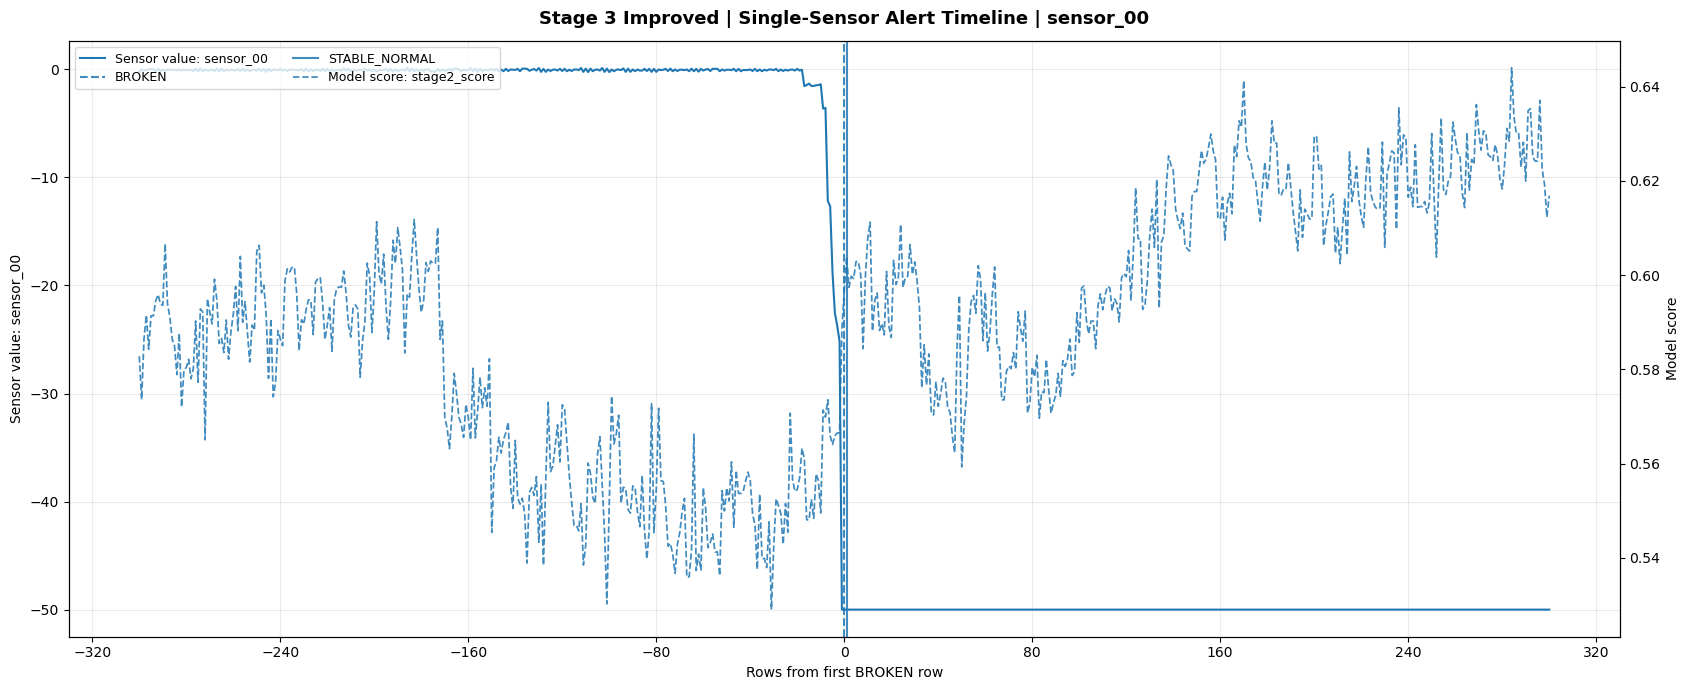

In [46]:

sensor_column_for_plot = resolve_sensor_column_for_plot(
    anomaly_timeline_dataframe,
    preferred_sensor_column=DEFAULT_SENSOR_FOR_TIMELINE,
)

timeline_fig = plot_anomaly_timeline_window(
    anomaly_timeline_dataframe,
    sensor_column=sensor_column_for_plot,
    center_on="broken",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

## Stacked Waveform and Isometric Plot

### Ask

Why create all-sensor waveform plots?

### Answer

A single sensor plot can miss broader system behavior.

The stacked waveform and isometric-style views help me inspect how many sensors are changing together, whether related sensors move at the same time, and whether the detected anomaly looks like a system pattern rather than a one-column spike.

In [47]:

def resolve_sensor_columns(dataframe: pd.DataFrame) -> list[str]:
    """
    Resolve raw pump sensor columns only.

    This avoids accidentally selecting derived boolean flag columns, profile
    columns, alert indicators, or other sensor-prefixed metadata columns.
    Expected raw sensor format: sensor_00, sensor_01, ..., sensor_51.
    """
    import re

    raw_sensor_pattern = re.compile(r"^sensor_\d{2}$")

    sensor_columns = [
        column_name
        for column_name in dataframe.columns
        if raw_sensor_pattern.match(column_name)
    ]

    if not sensor_columns:
        raise ValueError(
            "No raw sensor columns found. Expected columns like sensor_00, sensor_01, ..., sensor_51."
        )

    return sorted(sensor_columns)

#### Define display-only sensor normalization

This cell defines helper logic used by the surrounding `Stacked Waveform and Isometric Plot` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [48]:
def normalize_sensor_columns_for_plot(
    dataframe: pd.DataFrame,
    sensor_columns: list[str],
    method: str = "zscore",
) -> pd.DataFrame:
    """
    Normalize sensor columns for multi-sensor visualization only.

    This function is display-only. It does not change model inputs, saved
    timeline data, truth records, or exported artifacts.

    Safety fix:
    - Converts every selected column to numeric float before quantile math.
    - Boolean columns become 0.0 / 1.0 instead of bool dtype.
    - Fully missing or non-convertible columns become 0.0 for plotting.
    """
    out = dataframe.copy()

    for column in sensor_columns:
        if column not in out.columns:
            continue

        # Force numeric float dtype so pandas/numpy quantile cannot operate on bools.
        series = pd.to_numeric(out[column], errors="coerce").astype("float64")

        if series.notna().sum() == 0:
            out[column] = 0.0
            continue

        if method == "zscore":
            mean_value = float(series.mean())
            std_value = float(series.std(ddof=0))

            if std_value == 0 or np.isnan(std_value):
                out[column] = 0.0
            else:
                out[column] = (series - mean_value) / std_value

        elif method == "robust_zscore":
            median_value = float(series.median())
            q1_value = float(series.quantile(0.25))
            q3_value = float(series.quantile(0.75))
            iqr_value = q3_value - q1_value

            # IQR / 1.349 approximates standard deviation for normal-like data.
            robust_scale = iqr_value / 1.349 if iqr_value != 0 else np.nan

            if robust_scale == 0 or np.isnan(robust_scale):
                mad_value = float((series - median_value).abs().median())
                robust_scale = 1.4826 * mad_value

            if robust_scale == 0 or np.isnan(robust_scale):
                out[column] = 0.0
            else:
                out[column] = (series - median_value) / robust_scale

        elif method == "minmax":
            min_value = float(series.min())
            max_value = float(series.max())
            range_value = max_value - min_value

            if range_value == 0 or np.isnan(range_value):
                out[column] = 0.0
            else:
                out[column] = (series - min_value) / range_value

        else:
            raise ValueError(f"Unsupported normalization method: {method}")

    return out

#### Define display-only sensor normalization

This cell defines helper logic used by the surrounding `Stacked Waveform and Isometric Plot` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [49]:
def plot_all_sensors_stacked_waveform(
    dataframe: pd.DataFrame,
    sensor_columns: Optional[list[str]] = None,
    center_on: str = "broken",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    normalize_method: str = PLOT_SENSOR_NORMALIZATION_METHOD,
    lane_spacing: float = 4.0,
    amplitude_scale: float = 0.9,
    add_isometric_x_shift: bool = True,
    x_shift_per_sensor: float = 0.15,
    figsize: tuple[int, int] = (18, 13),
) -> Figure:
    """
    Plot all sensors as stacked, normalized waveforms around the selected anchor.

    Each sensor is normalized independently for display. This lets you see
    simultaneous movement patterns across sensors without large-scale sensors
    visually dominating smaller-scale sensors.
    """
    out = dataframe.copy()

    if sensor_columns is None:
        sensor_columns_resolved: list[str] = resolve_sensor_columns(out)
    else:
        sensor_columns_resolved = [str(column_name) for column_name in sensor_columns]

    if not sensor_columns_resolved:
        raise ValueError("No sensor columns were resolved for stacked waveform plotting.")

    window_df, event_context = extract_centered_plot_window(
        out,
        target_flag_column=TARGET_FLAG_COLUMN,
        center_on=center_on,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    raw_center_index = event_context.get("center_plot_order_index")

    if raw_center_index is None:
        raise ValueError(
            "center_plot_order_index could not be resolved. "
            "Rerun extract_centered_plot_window() and verify the timeline event context."
        )

    center_index: int = int(raw_center_index)

    window_df = normalize_sensor_columns_for_plot(
        window_df,
        sensor_columns=sensor_columns_resolved,
        method=normalize_method,
    )

    x_values = window_df["relative_plot_index"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    add_alert_spans(
        ax,
        window_df,
        target_flag_column=TARGET_FLAG_COLUMN,
        x_column="relative_plot_index",
        alpha=PLOT_ALERT_SPAN_ALPHA,
    )

    y_tick_positions: list[float] = []
    y_tick_labels: list[str] = []

    for sensor_idx, sensor_column in enumerate(sensor_columns_resolved):
        lane_base = float(sensor_idx * lane_spacing)
        y_tick_positions.append(lane_base)
        y_tick_labels.append(sensor_column)

        x_plot = x_values + (sensor_idx * x_shift_per_sensor) if add_isometric_x_shift else x_values
        y_plot = lane_base + (
            pd.to_numeric(window_df[sensor_column], errors="coerce").to_numpy(dtype=float)
            * amplitude_scale
        )

        ax.plot(x_plot, y_plot, linewidth=0.9, alpha=0.9)

    y_min = -lane_spacing
    y_max = len(sensor_columns_resolved) * lane_spacing
    ax.set_ylim(y_min, y_max)

    add_event_reference_lines(
        ax,
        event_context,
        x_min=float(np.nanmin(x_values)),
        x_max=float(np.nanmax(x_values)),
        center_index=center_index,
    )

    center_label = "first BROKEN row" if center_on == "broken" else "first selected alert row"
    format_gold05_axis(
        ax,
        title=f"{PLOT_RUN_LABEL} | All-Sensor Stacked Waveform ({normalize_method})",
        xlabel=f"Rows from {center_label}",
        ylabel="Sensor lane",
    )

    ax.set_yticks(y_tick_positions)
    ax.set_yticklabels(y_tick_labels, fontsize=8)
    combine_legends(ax, loc="upper right", ncol=2)
    fig.tight_layout()

    return fig

#### Create Gold 05 anomaly timeline output

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

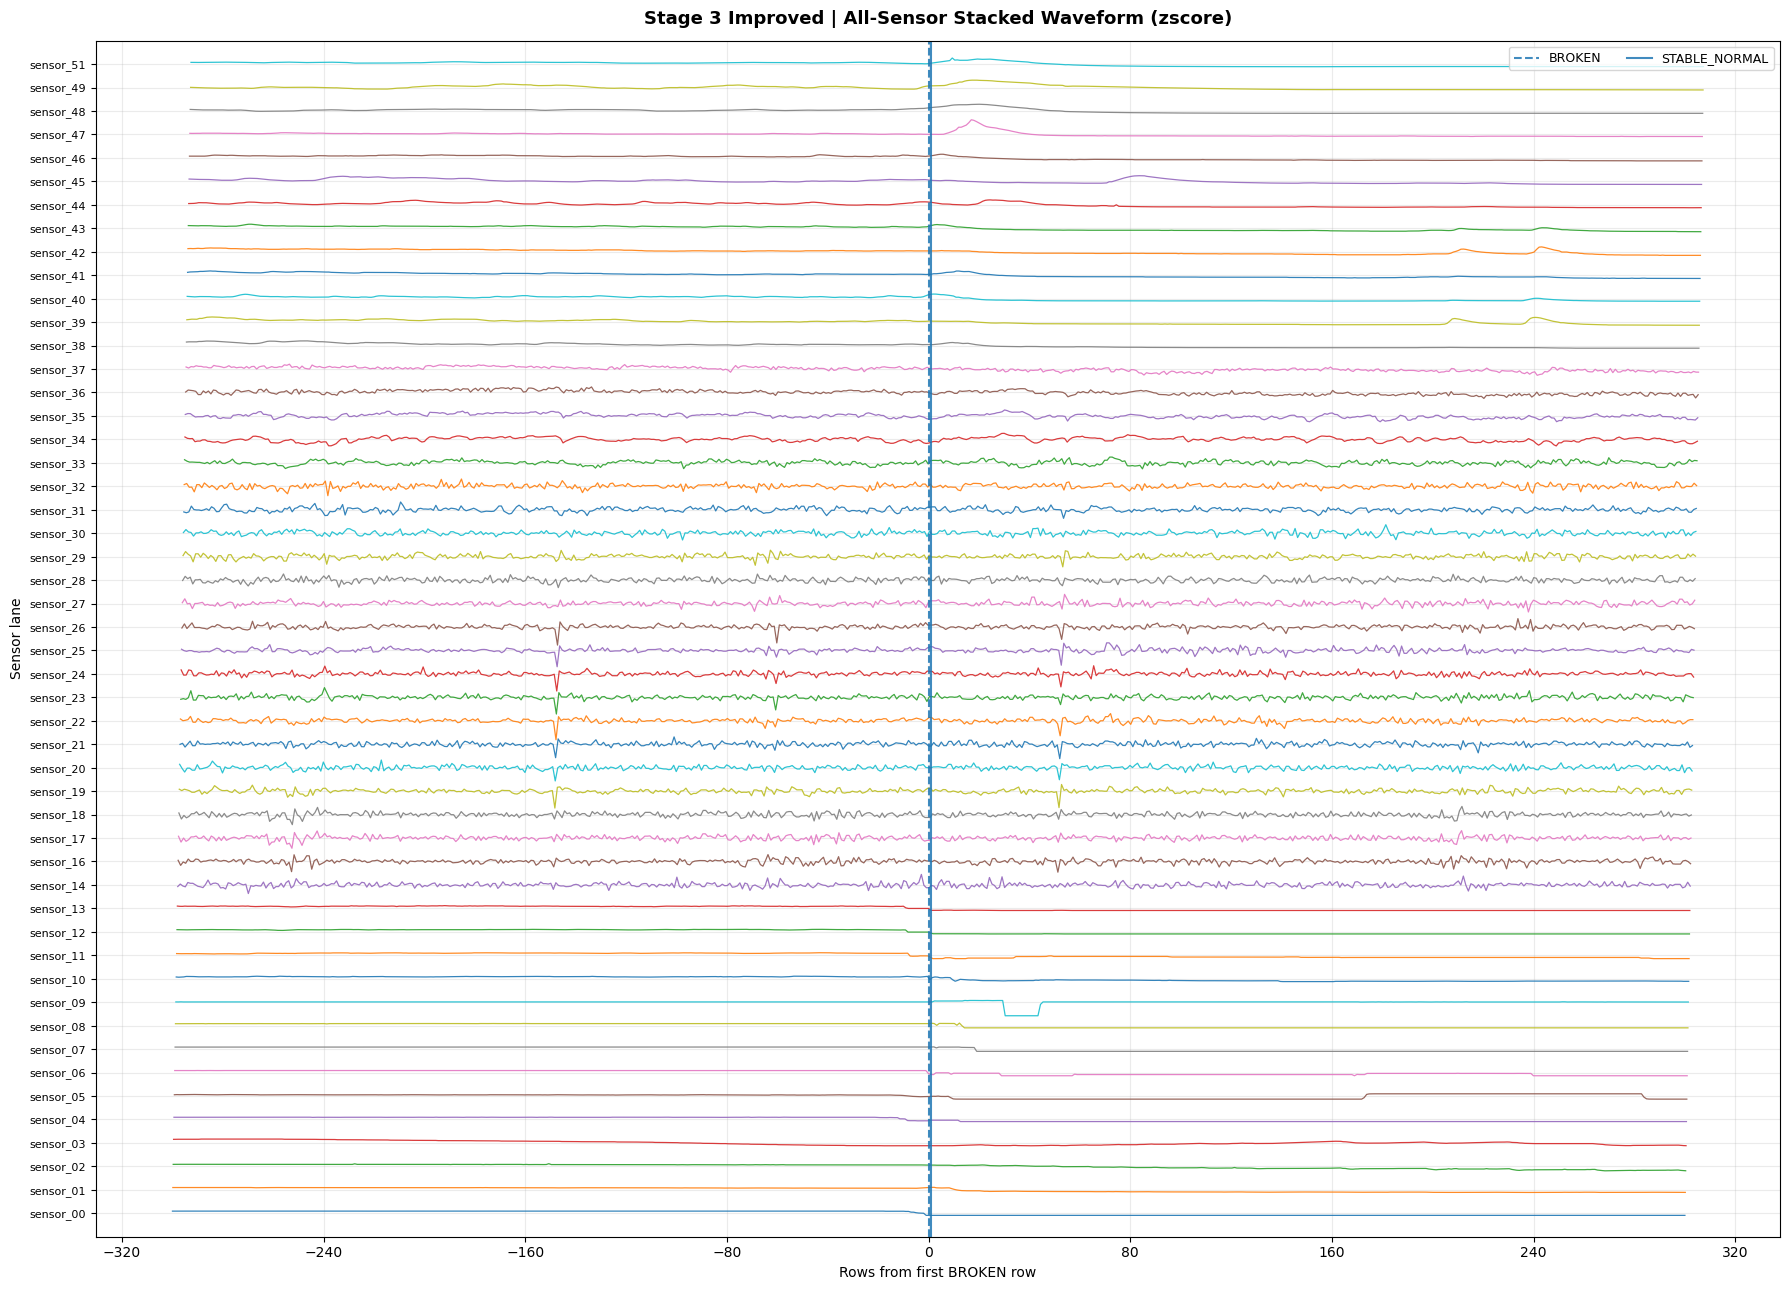

In [50]:

stacked_sensor_columns = resolve_sensor_columns(anomaly_timeline_dataframe)

stacked_waveform_fig = plot_all_sensors_stacked_waveform(
    anomaly_timeline_dataframe,
    sensor_columns=stacked_sensor_columns,
    center_on="broken",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
    normalize_method="zscore",
    lane_spacing=10.0,
    amplitude_scale=0.9,
    add_isometric_x_shift=True,
    x_shift_per_sensor=0.15,
)

plt.show()

## Baseline Versus Cascade Comparison Build

### Ask

Why compare baseline and cascade timelines here?

### Answer

The model summary metrics show overall performance, but the timeline comparison shows how the models behave around the same event window.

This helps me explain whether the cascade reduces alerts, delays alerts, improves focus, or changes the lead-time behavior compared with the baseline.

In [51]:

COMPARISON_RUN_KEY = "cascade_tuned"
# valid:
#   cascade_defaults
#   cascade_tuned
#   stage3_improved

baseline_payload = build_run_timeline_dataframe("baseline")
comparison_payload = build_run_timeline_dataframe(COMPARISON_RUN_KEY)

comparison_summary_df = build_comparison_summary_dataframe(
    [baseline_payload, comparison_payload]
)

ledger.add(
    kind="step",
    step="comparison_build",
    message="Built baseline vs comparison-run timeline payloads and summary dataframe.",
    why="Gold 05 should support direct baseline-vs-cascade timeline review.",
    consequence="Comparison plots and metrics can now be generated on aligned windows.",
    data={
        "comparison_run_key": COMPARISON_RUN_KEY,
        "baseline_row_count": int(len(baseline_payload["timeline_dataframe"])),
        "comparison_row_count": int(len(comparison_payload["timeline_dataframe"])),
    },
    logger=logger,
)

display(comparison_summary_df)

2026-06-09 06:57:41,014 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/baseline/scores/pump__gold__baseline_results.pkl
2026-06-09 06:58:16,778 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/cascade_tuned/scores/pump__gold__cascade_tuned_results.pkl
2026-06-09 06:58:46,593 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T06:58:46.593453+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'comparison_build', 'message': 'Built baseline vs comparison-run timeline payloads and summary dataframe.', 'why': 'Gold 05 should support direct baseline-vs-cascade timeline review.', 'consequence': 'Comparison plots and metrics can now be generated on aligned windows.', 'data': {'comparison_run_key': 'cascade_tuned', 'baseline_row_count': 220320, 'comparison_row_count': 220320}}


,selected_run_key,plot_run_label,run_family,target_flag_column,primary_score_column,primary_decision_column,row_count,first_alert_plot_order_index,first_broken_plot_order_index,recovery_end_plot_order_index,lead_rows_to_failure,lead_time_minutes_to_failure,total_final_alert_rows,detection_class_counts,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index
0,baseline,Baseline Isolation Forest,baseline,baseline_flag,baseline_score,baseline_decision,220320,274,17155,18692,16881,16881,87735,"{'no_alert': 132585, 'false_positive': 81644, ...",NaN,NaN,NaN,NaN
1,cascade_tuned,Cascade Tuned,cascade,cascade_final_flag,stage2_score,stage2_model_decision,220320,5201,17155,18426,11954,11954,54598,"{'no_alert': 165722, 'false_positive': 53050, ...",260.0,5201.0,5201.0,5201.0


#### Define model lead-time comparison table

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

In [52]:

LEAD_TIME_RUN_KEYS = [
    "baseline",
    "cascade_defaults",
    "cascade_tuned",
    "stage3_improved",
    "stage3_medium",
    "stage3_strict",
]

lead_time_run_payloads = [
    build_run_timeline_dataframe(run_key)
    for run_key in LEAD_TIME_RUN_KEYS
]

lead_time_comparison_df = build_comparison_summary_dataframe(
    lead_time_run_payloads
)

lead_time_comparison_columns = [
    "selected_run_key",
    "plot_run_label",
    "run_family",
    "target_flag_column",
    "first_alert_plot_order_index",
    "first_broken_plot_order_index",
    "lead_rows_to_failure",
    "lead_time_minutes_to_failure",
    "total_final_alert_rows",
    "first_stage1_flag_plot_order_index",
    "first_stage2_flag_plot_order_index",
    "first_stage2_raw_flag_plot_order_index",
    "first_cascade_final_flag_plot_order_index",
]

lead_time_comparison_columns = [
    column_name
    for column_name in lead_time_comparison_columns
    if column_name in lead_time_comparison_df.columns
]

lead_time_comparison_df = lead_time_comparison_df.loc[
    :,
    lead_time_comparison_columns,
].copy()

display(lead_time_comparison_df)



# ------------------------------------------------------------
# Save multi-run lead-time comparison artifact
# ------------------------------------------------------------

ANOMALY_DETECTION_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

multi_run_lead_time_path = (
    ANOMALY_DETECTION_SUMMARY_DIR / "multi_run_lead_time_comparison.csv"
)

lead_time_comparison_df.to_csv(
    multi_run_lead_time_path,
    index=False,
)

print(f"Saved multi-run lead-time comparison: {multi_run_lead_time_path}")

ledger.add(
    kind="step",
    step="multi_run_lead_time_comparison",
    message="Built multi-run lead-time comparison across baseline, cascade, and Stage 3 operating modes.",
    why="Precision/recall alone does not show whether a model provides useful early warning.",
    consequence="Gold 05 can now compare detection timing across operating modes.",
    data={
        "run_keys": LEAD_TIME_RUN_KEYS,
        "row_count": int(len(lead_time_comparison_df)),
        "output_path": str(multi_run_lead_time_path),
    },
    logger=logger,
)

2026-06-09 06:58:46,660 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/baseline/scores/pump__gold__baseline_results.pkl
2026-06-09 06:59:15,141 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/cascade_defaults/scores/pump__gold__cascade_defaults_results.pkl
2026-06-09 06:59:46,034 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/cascade_tuned/scores/pump__gold__cascade_tuned_results.pkl
2026-06-09 07:00:20,229 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/cascade_stage3_improved/scores/pump__gold__cascade_stage3_improved_results.pkl
2026-06-09 07:01:12,543 | INFO | capstone.gold.anomaly_detection | Loading selected results from artifact path: /workspace/artifacts/gold/pump/cascade_stage3_improved/scores/pu

,selected_run_key,plot_run_label,run_family,target_flag_column,first_alert_plot_order_index,first_broken_plot_order_index,lead_rows_to_failure,lead_time_minutes_to_failure,total_final_alert_rows,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index
0,baseline,Baseline Isolation Forest,baseline,baseline_flag,274,17155,16881,16881,87735,NaN,NaN,NaN,NaN
1,cascade_defaults,Cascade Defaults,cascade,cascade_final_flag,5202,17155,11953,11953,69362,260.0,5202.0,5202.0,5202.0
2,cascade_tuned,Cascade Tuned,cascade,cascade_final_flag,5201,17155,11954,11954,54598,260.0,5201.0,5201.0,5201.0
3,stage3_improved,Stage 3 Improved,cascade,cascade_final_flag,5201,17155,11954,11954,37024,260.0,5201.0,5201.0,5201.0
4,stage3_medium,Stage 3 Medium,cascade,cascade_stage3_medium_flag,5201,17155,11954,11954,38213,260.0,5201.0,5201.0,5201.0
5,stage3_strict,Stage 3 Strict,cascade,cascade_stage3_strict_flag,17979,17155,-824,-824,210,260.0,5201.0,5201.0,5201.0


2026-06-09 07:02:14,463 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T07:02:14.463491+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'multi_run_lead_time_comparison', 'message': 'Built multi-run lead-time comparison across baseline, cascade, and Stage 3 operating modes.', 'why': 'Precision/recall alone does not show whether a model provides useful early warning.', 'consequence': 'Gold 05 can now compare detection timing across operating modes.', 'data': {'run_keys': ['baseline', 'cascade_defaults', 'cascade_tuned', 'stage3_improved', 'stage3_medium', 'stage3_strict'], 'row_count': 6, 'output_path': '/workspace/artifacts/gold/pump/anomaly_detection/summaries/multi_run_lead_time_comparison.csv'}}


Saved multi-run lead-time comparison: /workspace/artifacts/gold/pump/anomaly_detection/summaries/multi_run_lead_time_comparison.csv


{'ts_utc': '2026-06-09T07:02:14.463491+00:00',
 'stage': 'gold',
 'recipe': 'gold_anomaly_detection__20260609T065634Z',
 'kind': 'step',
 'step': 'multi_run_lead_time_comparison',
 'message': 'Built multi-run lead-time comparison across baseline, cascade, and Stage 3 operating modes.',
 'why': 'Precision/recall alone does not show whether a model provides useful early warning.',
 'consequence': 'Gold 05 can now compare detection timing across operating modes.',
 'data': {'run_keys': ['baseline',
   'cascade_defaults',
   'cascade_tuned',
   'stage3_improved',
   'stage3_medium',
   'stage3_strict'],
  'row_count': 6,
  'output_path': '/workspace/artifacts/gold/pump/anomaly_detection/summaries/multi_run_lead_time_comparison.csv'}}

# Multi-Run Lead-Time Comparison Chart

,selected_run_key,plot_run_label,run_family,target_flag_column,first_alert_plot_order_index,first_broken_plot_order_index,lead_rows_to_failure,lead_time_minutes_to_failure,total_final_alert_rows,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index
0,baseline,Baseline Isolation Forest,baseline,baseline_flag,274,17155,16881,16881,87735,NaN,NaN,NaN,NaN
1,cascade_defaults,Cascade Defaults,cascade,cascade_final_flag,5202,17155,11953,11953,69362,260.0,5202.0,5202.0,5202.0
2,cascade_tuned,Cascade Tuned,cascade,cascade_final_flag,5201,17155,11954,11954,54598,260.0,5201.0,5201.0,5201.0
3,stage3_improved,Stage 3 Improved,cascade,cascade_final_flag,5201,17155,11954,11954,37024,260.0,5201.0,5201.0,5201.0
4,stage3_medium,Stage 3 Medium,cascade,cascade_stage3_medium_flag,5201,17155,11954,11954,38213,260.0,5201.0,5201.0,5201.0
5,stage3_strict,Stage 3 Strict,cascade,cascade_stage3_strict_flag,17979,17155,-824,-824,210,260.0,5201.0,5201.0,5201.0


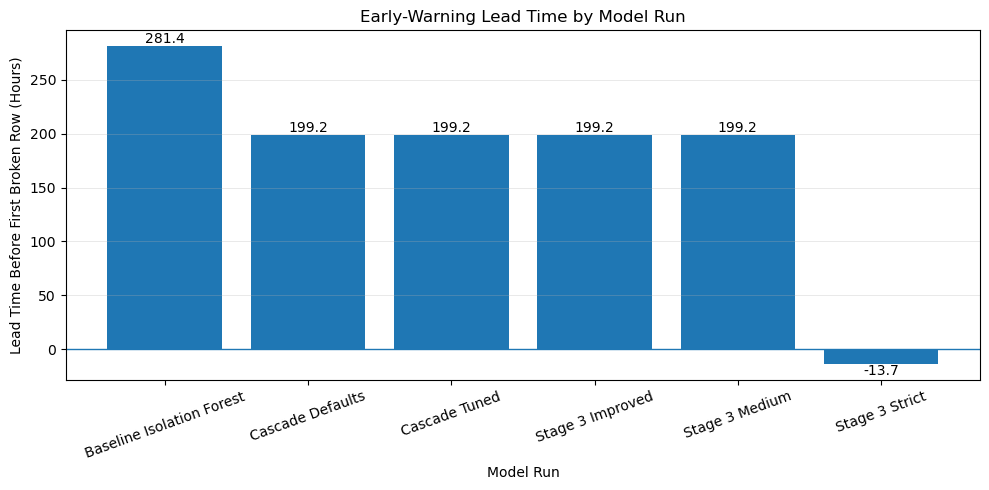

Saved multi-run lead-time chart: /workspace/artifacts/gold/pump/anomaly_detection/plots/stage3_improved__multi_run_lead_time_comparison.png


In [53]:


multi_run_lead_time_path = (
    ANOMALY_DETECTION_SUMMARY_DIR
    / "multi_run_lead_time_comparison.csv"
)

multi_run_lead_time_dataframe = pd.read_csv(multi_run_lead_time_path)

display(multi_run_lead_time_dataframe)

plot_frame = multi_run_lead_time_dataframe.copy()

plot_frame["lead_time_hours_to_failure"] = (
    plot_frame["lead_time_minutes_to_failure"] / 60
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    plot_frame["plot_run_label"],
    plot_frame["lead_time_hours_to_failure"],
)

ax.axhline(0, linewidth=1)
ax.set_title("Early-Warning Lead Time by Model Run")
ax.set_ylabel("Lead Time Before First Broken Row (Hours)")
ax.set_xlabel("Model Run")
ax.grid(axis="y", linewidth=0.5, alpha=0.4)

for bar, value in zip(bars, plot_frame["lead_time_hours_to_failure"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.1f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.xticks(rotation=20)
plt.tight_layout()

lead_time_plot_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"{SELECTED_RUN_KEY}__multi_run_lead_time_comparison.png"
)

fig.savefig(lead_time_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved multi-run lead-time chart: {lead_time_plot_path}")

## Baseline Versus Cascade Overlay Plot

### Ask

What does the overlay plot help me see?

### Answer

The overlay plot places baseline and cascade behavior into the same timeline context.

This makes it easier to compare when each model alerts, how dense the alerts are, and whether the cascade is acting as a useful filter after the broader baseline-style detection.

In [54]:
def plot_comparison_overlay(
    baseline_payload: dict[str, Any],
    comparison_payload: dict[str, Any],
    sensor_column: str,
    center_on: str = "broken",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    figsize: tuple[int, int] = (17, 8),
) -> Figure:
    baseline_df = baseline_payload["timeline_dataframe"].copy()
    comparison_df = comparison_payload["timeline_dataframe"].copy()

    baseline_target_flag_column = baseline_payload["target_flag_column"]
    comparison_target_flag_column = comparison_payload["target_flag_column"]

    baseline_score_column = baseline_payload["primary_score_column"]
    comparison_score_column = comparison_payload["primary_score_column"]

    baseline_window_df, baseline_context = extract_centered_plot_window(
        baseline_df,
        target_flag_column=baseline_target_flag_column,
        center_on=center_on,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    comparison_window_df, comparison_context = extract_centered_plot_window(
        comparison_df,
        target_flag_column=comparison_target_flag_column,
        center_on=center_on,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    fig, ax1 = plt.subplots(figsize=figsize)

    ax1.plot(
        baseline_window_df["relative_plot_index"],
        pd.to_numeric(baseline_window_df[sensor_column], errors="coerce"),
        linewidth=1.35,
        alpha=0.9,
        label=f"{baseline_payload['plot_run_label']} sensor",
    )
    ax1.plot(
        comparison_window_df["relative_plot_index"],
        pd.to_numeric(comparison_window_df[sensor_column], errors="coerce"),
        linewidth=1.35,
        alpha=0.9,
        label=f"{comparison_payload['plot_run_label']} sensor",
    )

    baseline_alert_df = baseline_window_df.loc[
        baseline_window_df[baseline_target_flag_column].fillna(0).astype(int) == 1
    ].copy()
    if not baseline_alert_df.empty:
        ax1.scatter(
            baseline_alert_df["relative_plot_index"],
            pd.to_numeric(baseline_alert_df[sensor_column], errors="coerce"),
            s=PLOT_ALERT_MARKER_SIZE,
            label=f"{baseline_payload['plot_run_label']} alerts",
            zorder=4,
        )

    comparison_alert_df = comparison_window_df.loc[
        comparison_window_df[comparison_target_flag_column].fillna(0).astype(int) == 1
    ].copy()
    if not comparison_alert_df.empty:
        ax1.scatter(
            comparison_alert_df["relative_plot_index"],
            pd.to_numeric(comparison_alert_df[sensor_column], errors="coerce"),
            s=PLOT_ALERT_MARKER_SIZE,
            marker="x",
            label=f"{comparison_payload['plot_run_label']} alerts",
            zorder=4,
        )

    ax1.axvline(0, linestyle="--", alpha=PLOT_EVENT_ALPHA, label=f"Center: {center_on}")

    ax2 = ax1.twinx()

    if baseline_score_column is not None and baseline_score_column in baseline_window_df.columns:
        ax2.plot(
            baseline_window_df["relative_plot_index"],
            pd.to_numeric(baseline_window_df[baseline_score_column], errors="coerce"),
            linestyle="--",
            linewidth=1.1,
            alpha=0.75,
            label=f"{baseline_payload['plot_run_label']} score",
        )

    if comparison_score_column is not None and comparison_score_column in comparison_window_df.columns:
        ax2.plot(
            comparison_window_df["relative_plot_index"],
            pd.to_numeric(comparison_window_df[comparison_score_column], errors="coerce"),
            linestyle=":",
            linewidth=1.1,
            alpha=0.75,
            label=f"{comparison_payload['plot_run_label']} score",
        )

    ax2.set_ylabel("Model score")
    ax2.grid(False)

    center_label = "first BROKEN row" if center_on == "broken" else "first selected alert row"
    format_gold05_axis(
        ax1,
        title=f"Baseline vs {comparison_payload['plot_run_label']} | {sensor_column}",
        xlabel=f"Rows from {center_label}",
        ylabel=f"Sensor value: {sensor_column}",
    )

    combine_legends(ax1, ax2=ax2, loc="upper left", ncol=2)
    fig.tight_layout()

    return fig

#### Generate focused anomaly timeline plot

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

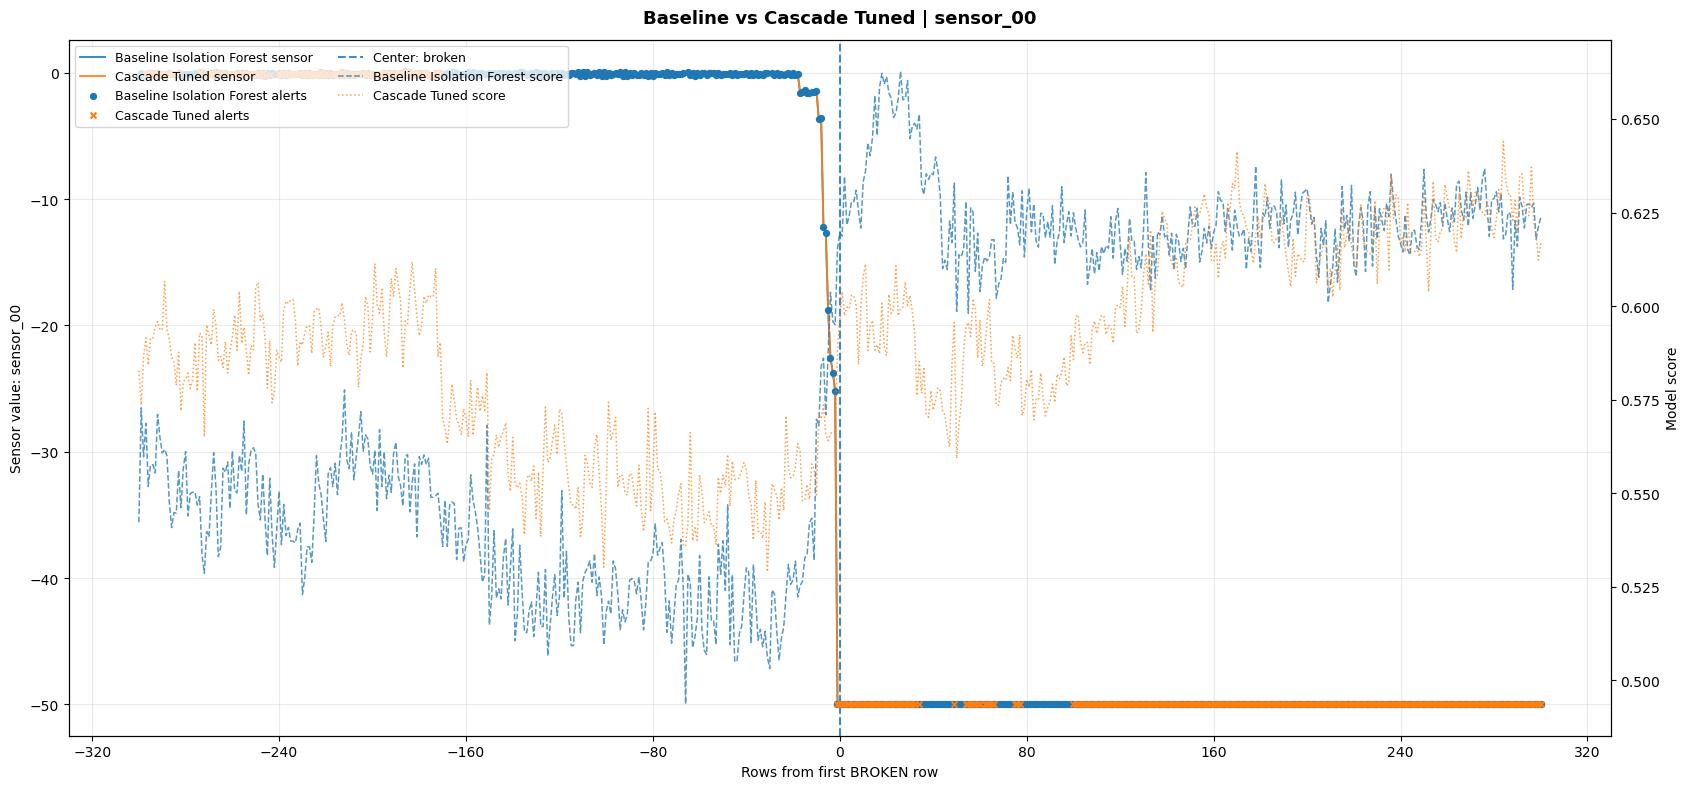

In [55]:

comparison_sensor_column = resolve_sensor_column_for_plot(
    baseline_payload["timeline_dataframe"],
    preferred_sensor_column=DEFAULT_SENSOR_FOR_TIMELINE,
)

comparison_fig = plot_comparison_overlay(
    baseline_payload=baseline_payload,
    comparison_payload=comparison_payload,
    sensor_column=comparison_sensor_column,
    center_on="broken",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

## All-Sensor Heatmap

### Ask

Why build an all-sensor heatmap?

### Answer

The heatmap gives me a compact view of many sensors over time.

This helps reveal whether the anomaly appears as a broad multi-sensor shift, a narrow sensor-specific failure, or a combination of both.

In [56]:
def build_sensor_matrix_for_plot(
    dataframe: pd.DataFrame,
    *,
    sensor_columns: list[str],
    time_axis_column: str,
    start_index: int,
    end_index: int,
    normalize_method: Optional[str] = None,
    clip_value: Optional[float] = None,
) -> tuple[pd.DataFrame, np.ndarray, list[str], np.ndarray]:
    """
    Build a numeric sensor matrix for heatmap / 3D plotting.

    Returns
    -------
    window_df:
        Filtered dataframe for the requested plotting window.

    x_values:
        Numeric x-axis values.

    y_values:
        Sensor column labels.

    z_matrix:
        Numeric 2D matrix with shape: sensors x time.
    """
    out = dataframe.copy()

    if time_axis_column not in out.columns:
        raise ValueError(f"Missing time axis column: {time_axis_column}")

    available_sensor_columns = [
        column_name
        for column_name in sensor_columns
        if column_name in out.columns
    ]

    if not available_sensor_columns:
        raise ValueError("No requested sensor columns were found in the dataframe.")

    out[time_axis_column] = pd.to_numeric(
        out[time_axis_column],
        errors="coerce",
    )

    window_df = out.loc[
        out[time_axis_column].between(start_index, end_index)
    ].copy()

    if window_df.empty:
        raise ValueError(
            f"No rows found between {start_index} and {end_index} "
            f"using time axis column {time_axis_column}."
        )

    window_df = window_df.sort_values(time_axis_column).reset_index(drop=True)

    numeric_sensor_df = pd.DataFrame(index=window_df.index)

    dropped_sensor_columns: list[str] = []

    for column_name in available_sensor_columns:
        converted_series = pd.to_numeric(
            window_df[column_name],
            errors="coerce",
        ).astype("float64")

        if converted_series.notna().sum() == 0:
            dropped_sensor_columns.append(column_name)
            continue

        numeric_sensor_df[column_name] = converted_series

    if dropped_sensor_columns:
        print(
            "Dropping fully non-numeric or fully missing sensor columns from plot:",
            dropped_sensor_columns,
        )

    if numeric_sensor_df.empty:
        raise ValueError(
            "After numeric conversion, no usable sensor columns remain for plotting."
        )

    if normalize_method is not None:
        normalized_sensor_df = normalize_sensor_columns_for_plot(
            numeric_sensor_df,
            sensor_columns=numeric_sensor_df.columns.tolist(),
            method=normalize_method,
        )

        numeric_sensor_df = normalized_sensor_df.loc[:, numeric_sensor_df.columns]

    x_values = pd.to_numeric(
        window_df[time_axis_column],
        errors="coerce",
    ).to_numpy(dtype=float)

    y_values = numeric_sensor_df.columns.tolist()

    # sensors x time
    z_matrix = numeric_sensor_df.to_numpy(dtype=float).T

    if clip_value is not None:
        z_matrix = np.clip(z_matrix, -float(clip_value), float(clip_value))

    return window_df, x_values, y_values, z_matrix

#### Define all-sensor heatmap plot

This cell defines helper logic used by the surrounding `All-Sensor Heatmap` section. Keeping the helper directly before its use makes the notebook assumptions visible and easier to audit.

In [57]:
def plot_all_sensors_heatmap(
    dataframe: pd.DataFrame,
    sensor_columns: Optional[list[str]] = None,
    center_on: str = "broken",
    time_axis_column: str = "plot_order_index",
    rows_before: int = PLOT_WINDOW_BEFORE_CENTER,
    rows_after: int = PLOT_WINDOW_AFTER_CENTER,
    normalize_method: Optional[str] = PLOT_SENSOR_NORMALIZATION_METHOD,
    clip_value: Optional[float] = PLOT_SENSOR_CLIP_VALUE,
    figsize: tuple[int, int] = (17, 10),
) -> Figure:
    out = dataframe.copy()

    if sensor_columns is None:
        sensor_columns_resolved: list[str] = resolve_sensor_columns(out)
    else:
        sensor_columns_resolved = [str(column_name) for column_name in sensor_columns]

    if not sensor_columns_resolved:
        raise ValueError("No sensor columns were resolved for heatmap plotting.")

    window_preview_df, event_context = extract_centered_plot_window(
        out,
        target_flag_column=TARGET_FLAG_COLUMN,
        center_on=center_on,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    raw_center_index = event_context.get("center_plot_order_index")

    if raw_center_index is None:
        raise ValueError(
            "center_plot_order_index could not be resolved. "
            "Rerun extract_centered_plot_window() and verify the timeline event context."
        )

    center_index: int = int(raw_center_index)
    start_index = int(window_preview_df[time_axis_column].min())
    end_index = int(window_preview_df[time_axis_column].max())

    window_df, x_values, y_values, z_matrix = build_sensor_matrix_for_plot(
        out,
        sensor_columns=sensor_columns_resolved,
        time_axis_column=time_axis_column,
        start_index=start_index,
        end_index=end_index,
        normalize_method=normalize_method,
        clip_value=clip_value,
    )

    x_values_relative = x_values - center_index
    window_df["relative_plot_index"] = x_values_relative

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        z_matrix,
        aspect="auto",
        interpolation="nearest",
        extent=(
            float(np.nanmin(x_values_relative)),
            float(np.nanmax(x_values_relative)),
            float(len(y_values) - 0.5),
            -0.5,
        ),
    )

    add_event_reference_lines(
        ax,
        event_context,
        x_min=float(np.nanmin(x_values_relative)),
        x_max=float(np.nanmax(x_values_relative)),
        center_index=center_index,
    )

    center_label = "first BROKEN row" if center_on == "broken" else "first selected alert row"

    format_gold05_axis(
        ax,
        title=f"{PLOT_RUN_LABEL} | All-Sensor Heatmap ({normalize_method})",
        xlabel=f"Rows from {center_label}",
        ylabel="Sensor",
        grid=False,
    )

    ax.set_yticks(np.arange(len(y_values)))
    ax.set_yticklabels(y_values, fontsize=8)
    combine_legends(ax, loc="upper right", ncol=2)

    colorbar_label = "Sensor value"
    if normalize_method is not None:
        colorbar_label = f"Sensor value ({normalize_method}, clipped ±{clip_value})"

    fig.colorbar(im, ax=ax, label=colorbar_label)
    fig.tight_layout()

    return fig

#### Create Gold 05 anomaly timeline output

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

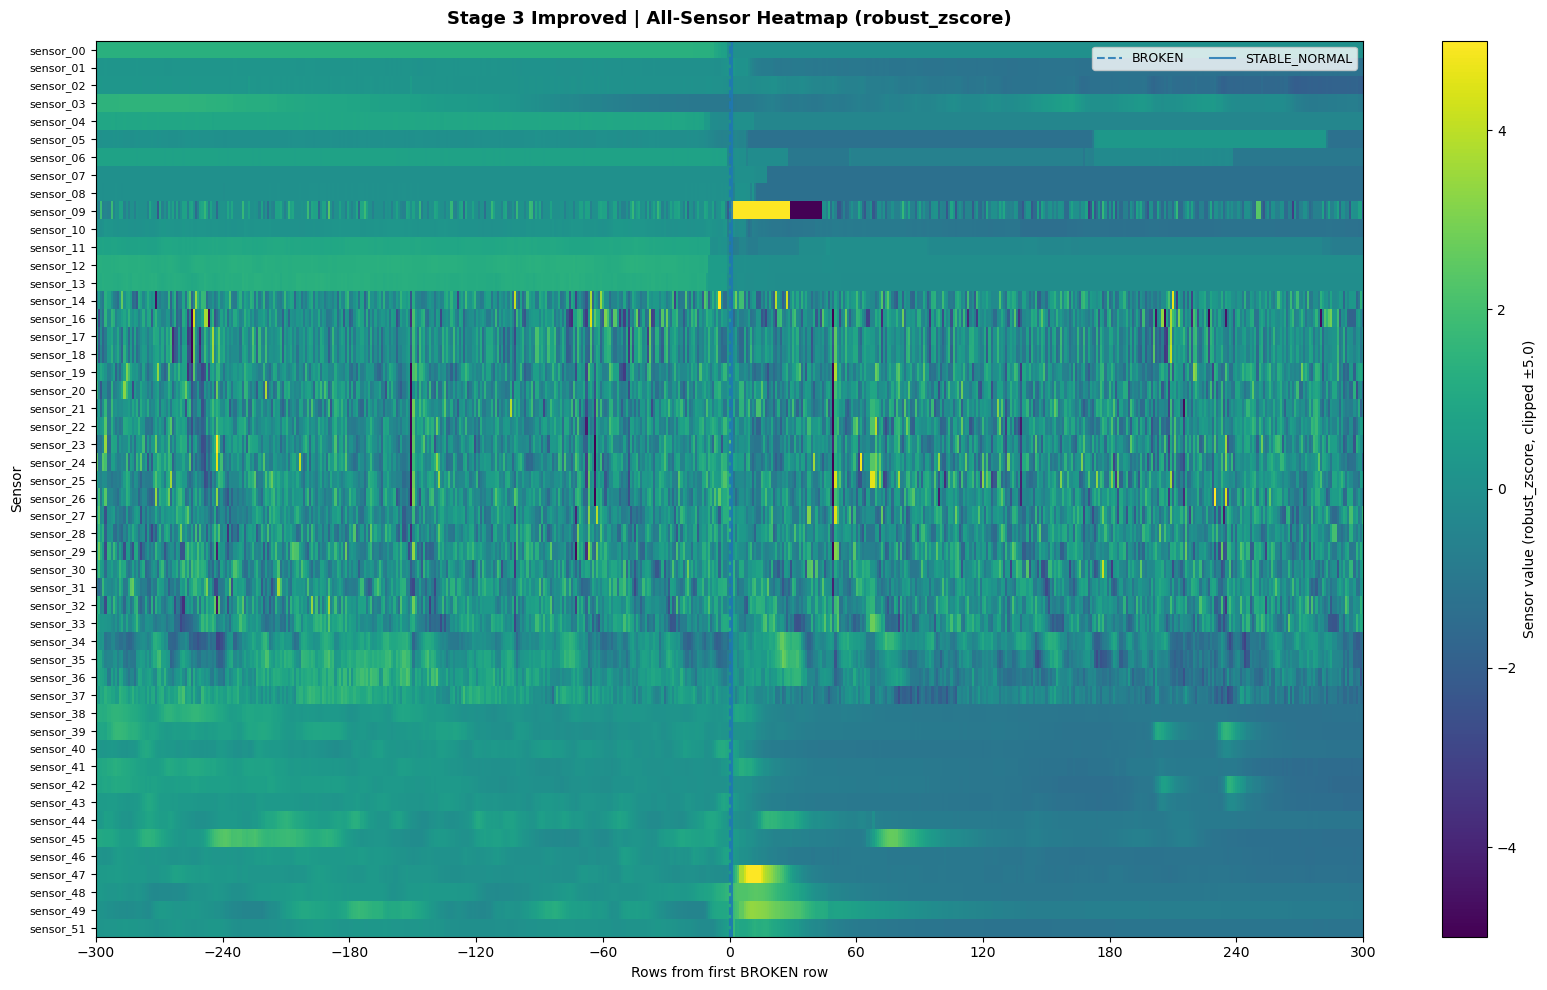

In [58]:

all_sensor_columns = resolve_sensor_columns(anomaly_timeline_dataframe)

all_sensor_heatmap_fig = plot_all_sensors_heatmap(
    anomaly_timeline_dataframe,
    sensor_columns=all_sensor_columns,
    center_on="broken",
    time_axis_column="plot_order_index",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

## All-Sensor 3D Surface

### Ask

Why include a 3D sensor surface view?

### Answer

The 3D surface is a visual diagnostic that shows sensor intensity across both time and sensor index.

It is not the main evaluation metric, but it helps communicate the shape of the anomaly pattern and whether the failure window has a visible multi-sensor structure.

In [59]:
def plot_all_sensors_3d_surface(
    dataframe: pd.DataFrame,
    *,
    sensor_columns: list[str],
    center_on: str = "broken",
    time_axis_column: str = "plot_order_index",
    rows_before: int = 300,
    rows_after: int = 100,
    normalize_method: Optional[str] = PLOT_SENSOR_NORMALIZATION_METHOD,
    clip_value: Optional[float] = PLOT_SENSOR_CLIP_VALUE,
    figsize: tuple[int, int] = (18, 10),
) -> Figure:
    """
    Plot all sensor values as a 3D surface.

    Notes
    -----
    - X axis = rows from the selected anchor
    - Y axis = numeric sensor position
    - Z axis = normalized sensor value by default
    """
    out = dataframe.copy()

    if time_axis_column not in out.columns:
        raise ValueError(f"Missing time axis column: {time_axis_column}")

    window_preview_df, event_context = extract_centered_plot_window(
        out,
        target_flag_column=TARGET_FLAG_COLUMN,
        center_on=center_on,
        rows_before=rows_before,
        rows_after=rows_after,
    )

    raw_center_index = event_context.get("center_plot_order_index")

    if raw_center_index is None:
        raise ValueError(
            "center_plot_order_index could not be resolved. "
            "Rerun extract_centered_plot_window() and verify the timeline event context."
        )

    center_index: int = int(raw_center_index)
    start_index = int(window_preview_df[time_axis_column].min())
    end_index = int(window_preview_df[time_axis_column].max())

    window_df, x_values, y_values, z_matrix = build_sensor_matrix_for_plot(
        out,
        sensor_columns=sensor_columns,
        time_axis_column=time_axis_column,
        start_index=start_index,
        end_index=end_index,
        normalize_method=normalize_method,
        clip_value=clip_value,
    )

    x_values = np.asarray(x_values, dtype=float) - center_index
    y_positions = np.arange(len(y_values), dtype=float)

    z_matrix = np.asarray(
        np.ma.filled(z_matrix, np.nan),
        dtype=float,
    )

    X, Y = np.meshgrid(x_values, y_positions)

    fig = Figure(figsize=figsize)
    ax = cast(Axes3D, fig.add_subplot(111, projection="3d"))

    ax.plot_surface(
        X,
        Y,
        z_matrix,
        linewidth=0,
        antialiased=True,
        alpha=0.92,
    )

    center_label = "first BROKEN row" if center_on == "broken" else "first selected alert row"

    ax.set_title(
        f"{PLOT_RUN_LABEL} | All-Sensor 3D Surface ({normalize_method})",
        pad=16,
    )
    ax.set_xlabel(f"Rows from {center_label}")
    ax.set_ylabel("Sensor")
    ax.set_zlabel(
        "Normalized sensor value" if normalize_method else "Sensor value"
    )

    # Label every few sensors to reduce crowding while preserving position.
    label_step = max(1, int(np.ceil(len(y_values) / 14)))
    labeled_positions = y_positions[::label_step]
    labeled_values = y_values[::label_step]

    ax.set_yticks(labeled_positions)
    ax.set_yticklabels(labeled_values)

    ax.view_init(elev=28, azim=-125)
    fig.tight_layout()

    return fig

#### Create Gold 05 anomaly timeline output

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

In [60]:


all_sensor_3d_fig = plot_all_sensors_3d_surface(
    anomaly_timeline_dataframe,
    sensor_columns=all_sensor_columns,
    center_on="broken",
    time_axis_column="plot_order_index",
    rows_before=PLOT_WINDOW_BEFORE_CENTER,
    rows_after=PLOT_WINDOW_AFTER_CENTER,
)

plt.show()

/tmp/ipykernel_95456/1457392237.py:100: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


## Top-K Alert Packet Review

### Ask

Why group alerts into packets?

### Answer

Individual alert rows can be noisy or too granular.

Alert packets group nearby alert rows into broader alert events. This makes it easier to review meaningful alert periods instead of treating every flagged row as a separate incident.

In [61]:
# ============================================================
# Top-K Alert Packet Review
# ============================================================

TOP_K_ALERT_PACKETS = 5

top_alert_packets_df = (
    alert_packet_summary_df.sort_values(
        by=["contains_pre_failure_alert", "rows_from_packet_start_to_broken", "packet_row_count"],
        ascending=[False, False, False],
    )
    .head(TOP_K_ALERT_PACKETS)
    .reset_index(drop=True)
    if not alert_packet_summary_df.empty
    else pd.DataFrame()
)

ledger.add(
    kind="step",
    step="top_k_alert_packets",
    message="Built top-k alert packet review dataframe.",
    why="Gold 05 should surface the most illustrative alert packets for focused inspection.",
    consequence="Notebook can highlight the strongest early-warning examples.",
    data={"top_k_alert_packets": int(len(top_alert_packets_df))},
    logger=logger,
)

display(top_alert_packets_df)

2026-06-09 07:02:21,362 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T07:02:21.362574+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'top_k_alert_packets', 'message': 'Built top-k alert packet review dataframe.', 'why': 'Gold 05 should surface the most illustrative alert packets for focused inspection.', 'consequence': 'Notebook can highlight the strongest early-warning examples.', 'data': {'top_k_alert_packets': 5}}


,alert_packet_id,packet_start_plot_order_index,packet_end_plot_order_index,packet_row_count,rows_from_packet_start_to_broken,contains_pre_failure_alert,contains_failure_hit,contains_recovery_alert,contains_stable_normal_alert
0,1,5201,5205,3,11954,1,0,0,0
1,2,17872,17872,1,-717,0,0,0,1
2,3,17879,17901,14,-724,0,0,0,1
3,4,17911,17926,12,-756,0,0,0,1
4,5,17933,17957,18,-778,0,0,0,1


## Packet-Centered Plot Helper

### Ask

Why build packet-centered plots?

### Answer

Packet-centered plots zoom in around the most important alert packets.

This gives me a focused way to review what the sensor timeline looked like before, during, and after the strongest alert periods.

In [62]:
# ============================================================
# Packet-Centered Plot Helper
# ============================================================

def plot_packet_centered_window(
    dataframe: pd.DataFrame,
    packet_start_plot_order_index: int,
    sensor_column: str,
    rows_before: int = 120,
    rows_after: int = 120,
    figsize: tuple[int, int] = (17, 7),
) -> Figure:
    out = dataframe.copy()

    min_plot_order_index = packet_start_plot_order_index - rows_before
    max_plot_order_index = packet_start_plot_order_index + rows_after

    window_df = out.loc[
        (out["plot_order_index"] >= min_plot_order_index)
        & (out["plot_order_index"] <= max_plot_order_index)
    ].copy()

    if window_df.empty:
        raise ValueError(
            f"No rows found around packet start {packet_start_plot_order_index}."
        )

    window_df["relative_plot_index"] = (
        window_df["plot_order_index"] - packet_start_plot_order_index
    )

    event_context = get_timeline_event_context(
        out,
        target_flag_column=TARGET_FLAG_COLUMN,
    )
    event_context["center_plot_order_index"] = packet_start_plot_order_index

    fig, ax1 = plt.subplots(figsize=figsize)

    x_values = window_df["relative_plot_index"].to_numpy(dtype=float)

    ax1.plot(
        x_values,
        pd.to_numeric(window_df[sensor_column], errors="coerce"),
        linewidth=1.5,
        label=f"Sensor value: {sensor_column}",
    )

    add_alert_spans(
        ax1,
        window_df,
        target_flag_column=TARGET_FLAG_COLUMN,
        x_column="relative_plot_index",
    )

    ax2 = None
    if PRIMARY_SCORE_COLUMN in window_df.columns:
        ax2 = ax1.twinx()
        ax2.plot(
            x_values,
            pd.to_numeric(window_df[PRIMARY_SCORE_COLUMN], errors="coerce"),
            linestyle="--",
            linewidth=1.15,
            alpha=0.85,
            label=f"Model score: {PRIMARY_SCORE_COLUMN}",
        )
        ax2.set_ylabel("Model score")
        ax2.grid(False)

    alert_df = window_df.loc[
        window_df[TARGET_FLAG_COLUMN].fillna(0).astype(int) == 1
    ].copy()
    if not alert_df.empty:
        ax1.scatter(
            alert_df["relative_plot_index"],
            pd.to_numeric(alert_df[sensor_column], errors="coerce"),
            s=PLOT_ALERT_MARKER_SIZE,
            label="Selected alert row",
            zorder=4,
        )

    ax1.axvline(0, linestyle="--", alpha=PLOT_EVENT_ALPHA, label="PACKET_START")

    add_event_reference_lines(
        ax1,
        event_context,
        x_min=float(np.nanmin(x_values)),
        x_max=float(np.nanmax(x_values)),
        center_index=packet_start_plot_order_index,
    )

    format_gold05_axis(
        ax1,
        title=f"{PLOT_RUN_LABEL} | Alert Packet Window | {sensor_column}",
        xlabel="Rows from packet start",
        ylabel=f"Sensor value: {sensor_column}",
    )

    combine_legends(ax1, ax2=ax2, loc="upper left", ncol=2)
    fig.tight_layout()

    return fig

#### Create Gold 05 anomaly timeline output

This cell builds a visual review artifact for interpretation and reporting. The plot is used to explain model behavior; it does not change the modeling inputs.

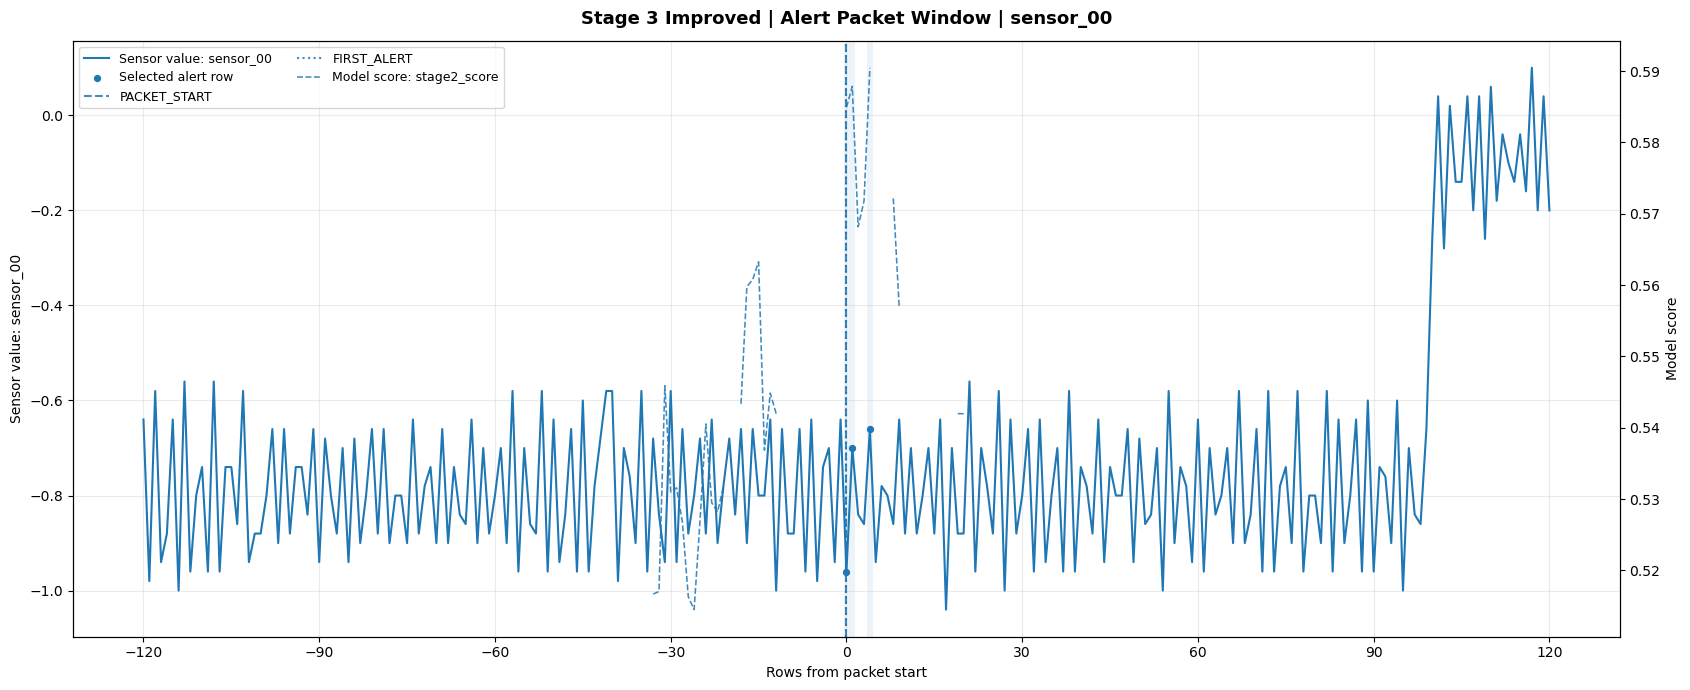

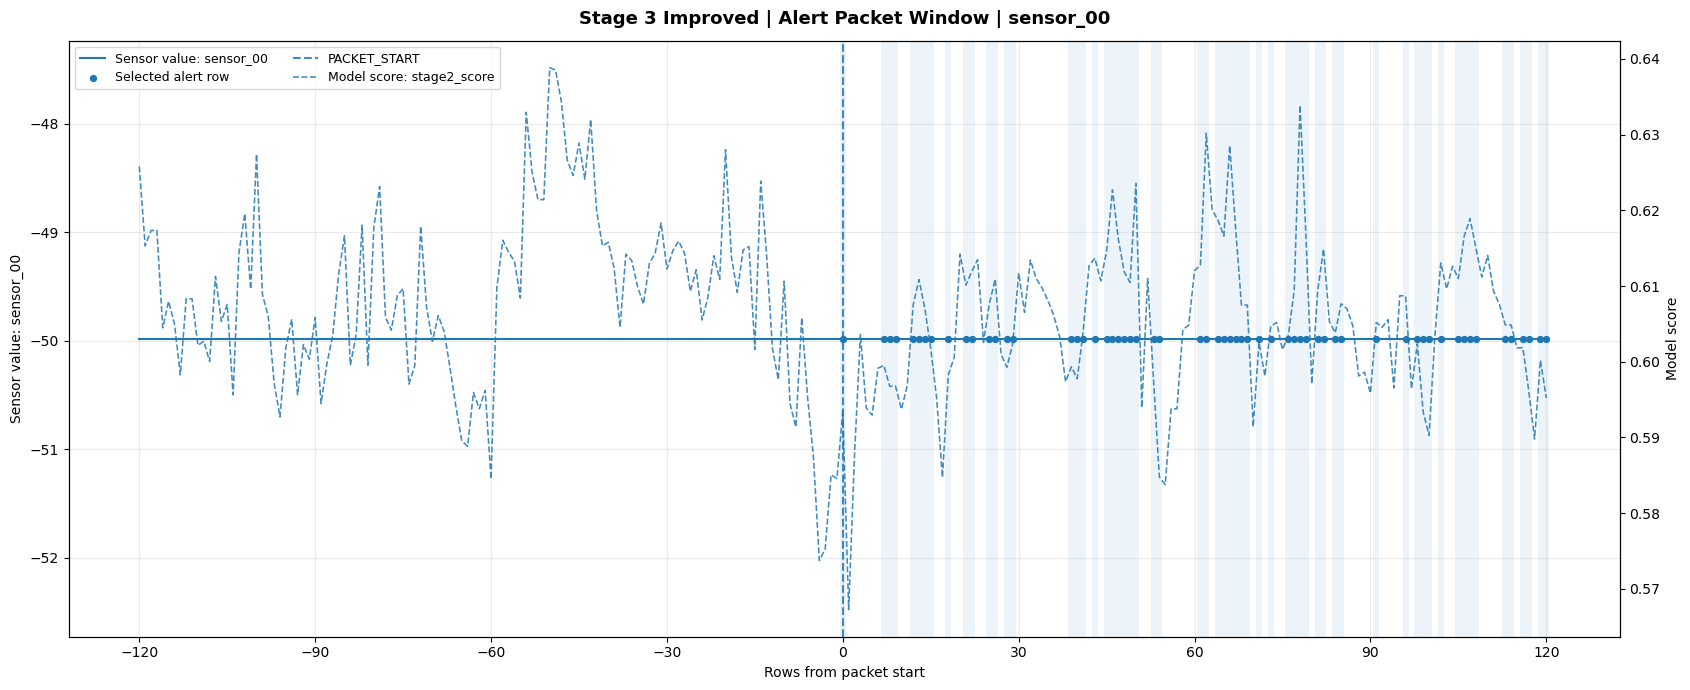

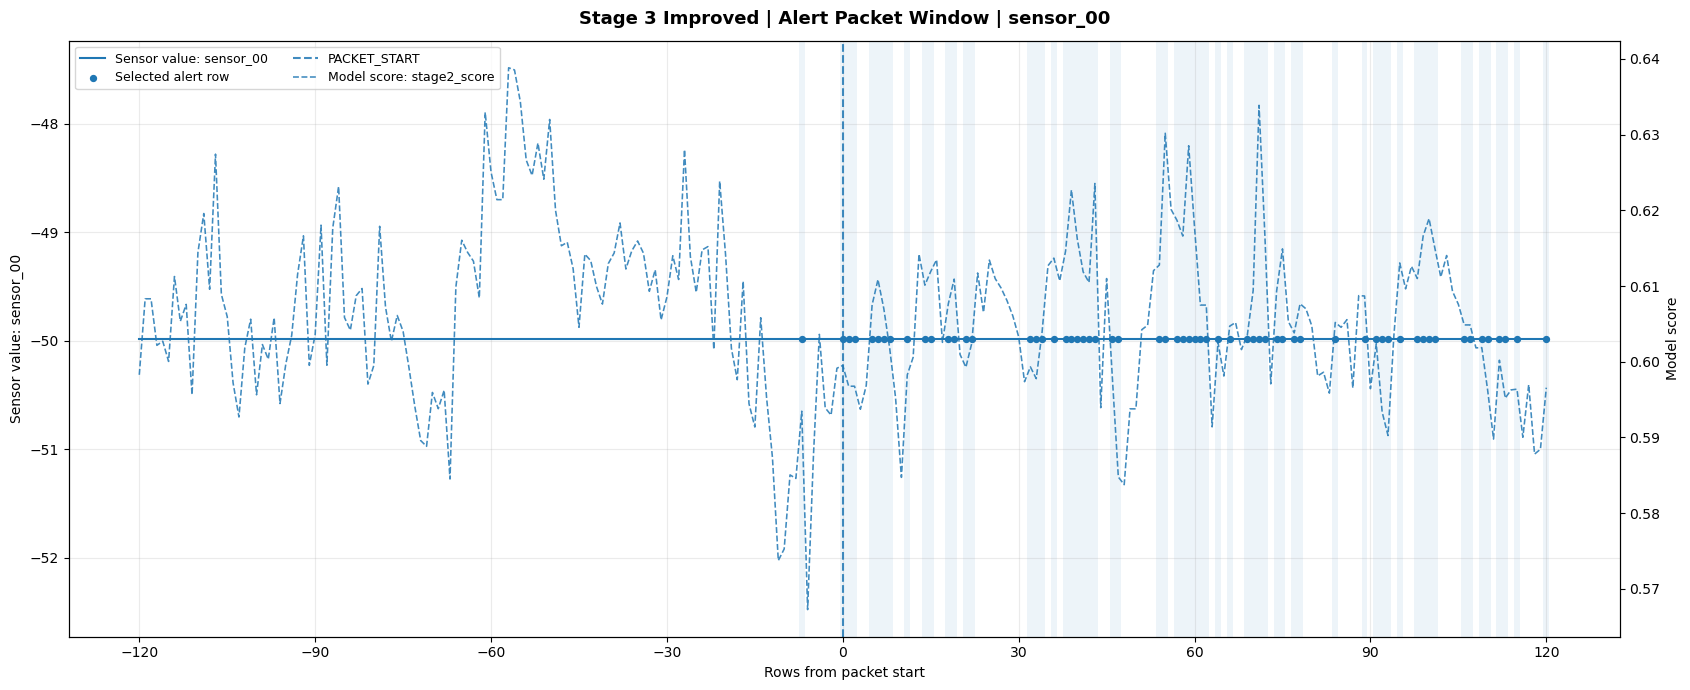

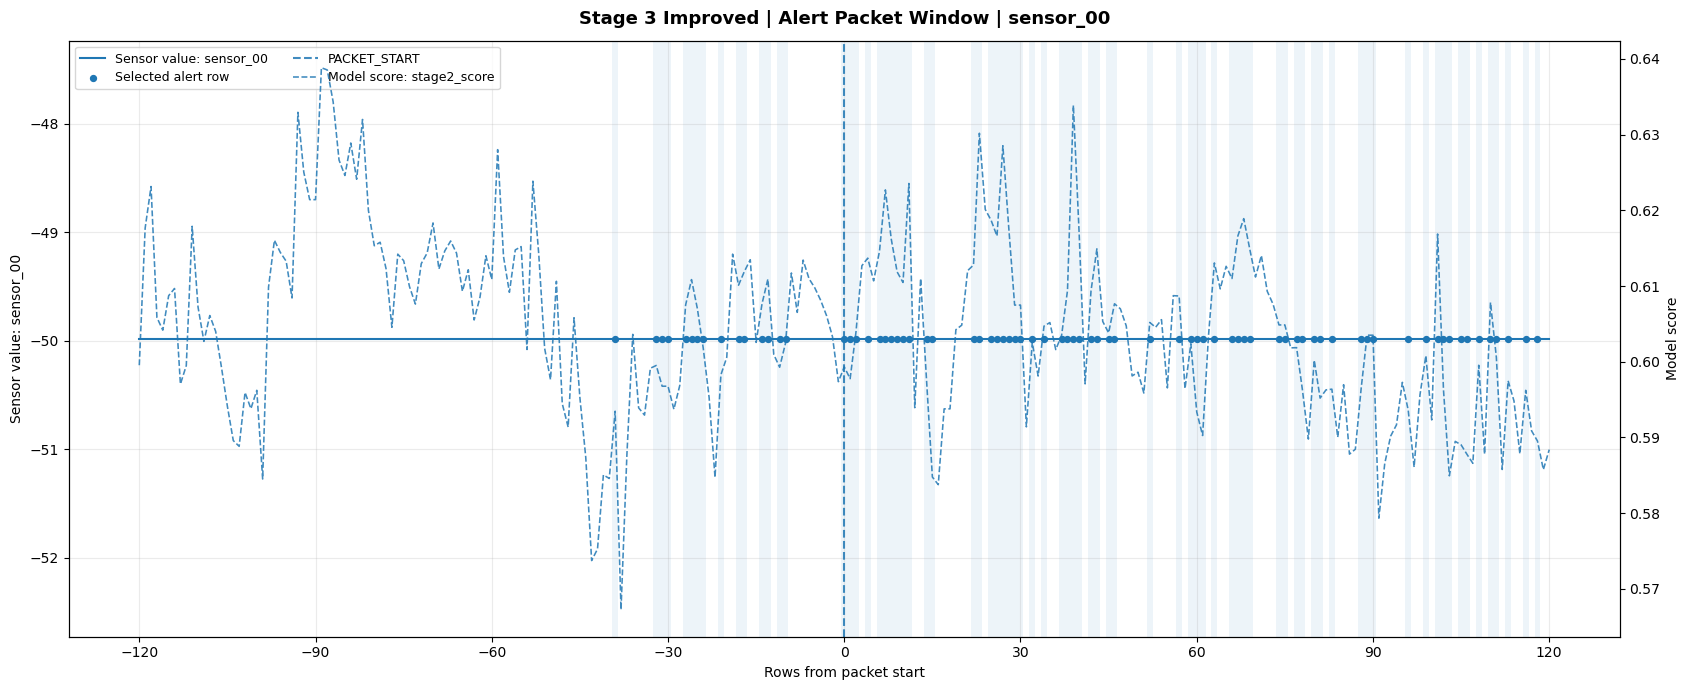

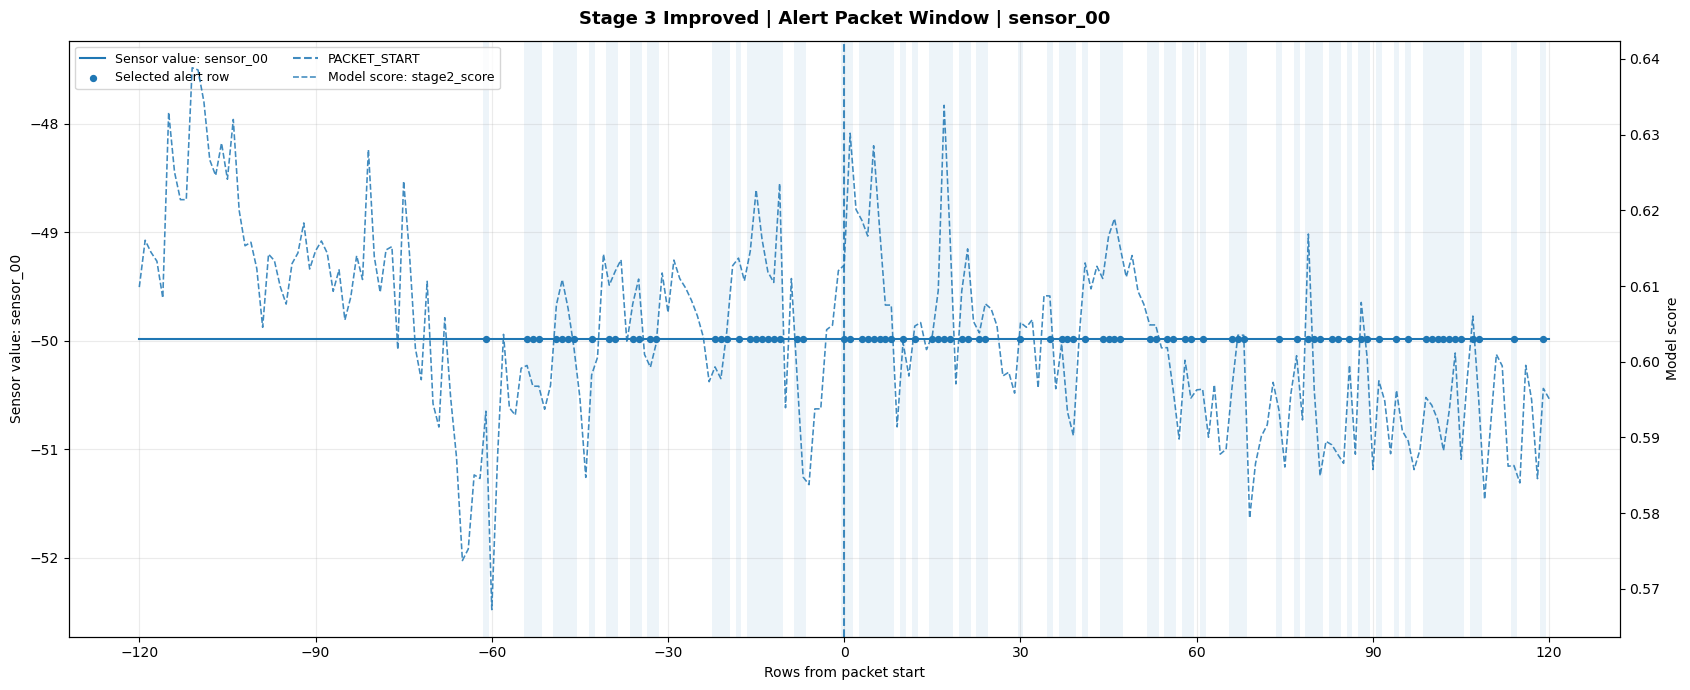

In [63]:

packet_figures = []

if not top_alert_packets_df.empty:
    packet_sensor_column = resolve_sensor_column_for_plot(
        anomaly_timeline_dataframe,
        preferred_sensor_column=DEFAULT_SENSOR_FOR_TIMELINE,
    )

    for _, packet_row in top_alert_packets_df.iterrows():
        packet_start_plot_order_index = int(packet_row["packet_start_plot_order_index"])
        packet_fig = plot_packet_centered_window(
            anomaly_timeline_dataframe,
            packet_start_plot_order_index=packet_start_plot_order_index,
            sensor_column=packet_sensor_column,
            rows_before=120,
            rows_after=120,
        )
        packet_figures.append((packet_start_plot_order_index, packet_fig))
        plt.show()

## Export Main Gold 05 Artifacts

### Ask

What gets exported here?

### Answer

This section saves the main Gold 05 outputs, including the timeline dataframe, failure lead-time summary, alert packet summary, and detection summary.

These exports make the anomaly review reusable outside the notebook and support the final project report.

In [64]:
# ============================================================
# Export Outputs
# ============================================================

timeline_export_path = (
    Path(ANOMALY_DETECTION_EXPORT_DIR)
    / f"{SELECTED_RUN_KEY}__timeline_export.parquet"
)

failure_lead_time_export_path = (
    Path(ANOMALY_DETECTION_SUMMARY_DIR)
    / f"{SELECTED_RUN_KEY}__failure_lead_time_summary.csv"
)

alert_packet_export_path = (
    Path(ANOMALY_DETECTION_PACKET_DIR)
    / f"{SELECTED_RUN_KEY}__alert_packet_summary.csv"
)

summary_payload_export_path = (
    Path(ANOMALY_DETECTION_SUMMARY_DIR)
    / f"{SELECTED_RUN_KEY}__detection_summary.json"
)

timeline_plot_export_path = (
    Path(ANOMALY_DETECTION_PLOT_DIR)
    / f"{SELECTED_RUN_KEY}__timeline_plot.png"
)

stacked_waveform_export_path = (
    Path(ANOMALY_DETECTION_PLOT_DIR)
    / f"{SELECTED_RUN_KEY}__stacked_sensor_waveform.png"
)



timeline_export_df = anomaly_timeline_dataframe.copy()

timeline_export_path = save_data(
    timeline_export_df,
    timeline_export_path.parent,
    timeline_export_path.name,
)

failure_lead_time_export_path = save_data(
    failure_lead_time_df,
    failure_lead_time_export_path.parent,
    failure_lead_time_export_path.name,
)

if not alert_packet_summary_df.empty:
    alert_packet_export_path = save_data(
        alert_packet_summary_df,
        alert_packet_export_path.parent,
        alert_packet_export_path.name,
    )

save_json(
    detection_summary_payload,
    summary_payload_export_path,
)

timeline_fig.savefig(timeline_plot_export_path, bbox_inches="tight")
stacked_waveform_fig.savefig(stacked_waveform_export_path, bbox_inches="tight")

ledger.add(
    kind="step",
    step="export_outputs",
    message="Exported Gold 05 timeline outputs and plots.",
    why="Notebook artifacts should be persisted for reporting, dashboarding, and downstream reuse.",
    consequence="Gold 05 artifacts are now available outside the active kernel.",
    data={
        "timeline_export_path": str(timeline_export_path),
        "failure_lead_time_export_path": str(failure_lead_time_export_path),
        "alert_packet_export_path": str(alert_packet_export_path),
        "summary_payload_export_path": str(summary_payload_export_path),
        "timeline_plot_export_path": str(timeline_plot_export_path),
        "stacked_waveform_export_path": str(stacked_waveform_export_path),
    },
    logger=logger,
)

print("Exports written:")
print(f" - {timeline_export_path}")
print(f" - {failure_lead_time_export_path}")
print(f" - {alert_packet_export_path}")
print(f" - {summary_payload_export_path}")
print(f" - {timeline_plot_export_path}")
print(f" - {stacked_waveform_export_path}")

2026-06-09 07:02:27,913 | INFO | capstone.file_io | Saving DataFrame to Parquet: /workspace/artifacts/gold/pump/anomaly_detection/exports/stage3_improved__timeline_export.parquet
2026-06-09 07:02:33,664 | INFO | capstone.file_io | Saved: stage3_improved__timeline_export.parquet | shape=(220320, 384) | columns=['meta__asset_id', 'meta__dataset', 'meta__episode_id', 'meta__event_id', 'meta__ingested_at_utc', 'meta__parent_truth_hash', 'meta__pipeline_mode', 'meta__record_id', 'meta__run_id', 'meta__source_file', 'meta__source_row_id', 'meta__split', 'meta__truth_hash', 'event_time', 'event_step', 'time_index', 'event_date', 'anomaly_flag', 'is_anomaly', 'is_normal', 'status_normal_value', 'sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sens

Exports written:
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/stage3_improved__timeline_export.parquet
 - /workspace/artifacts/gold/pump/anomaly_detection/summaries/stage3_improved__failure_lead_time_summary.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/packets/stage3_improved__alert_packet_summary.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/summaries/stage3_improved__detection_summary.json
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/stage3_improved__timeline_plot.png
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/stage3_improved__stacked_sensor_waveform.png


## Export Additional Review Tables

### Ask

Why save additional detected-row outputs?

### Answer

The additional exports provide focused review files for detected rows and other inspection tables.

These are useful for debugging, report writing, and downstream dashboard work because they avoid needing to manually filter the full timeline each time.

In [65]:


detected_rows_export_path = (
    ANOMALY_DETECTION_EXPORT_DIR
    / f"{SELECTED_RUN_KEY}__detected_rows_review.csv"
)

comparison_summary_export_path = (
    ANOMALY_DETECTION_SUMMARY_DIR
    / f"baseline_vs_{COMPARISON_RUN_KEY}__comparison_summary.csv"
)

comparison_plot_export_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"baseline_vs_{COMPARISON_RUN_KEY}__comparison_plot.png"
)

lead_time_comparison_export_path = (
    ANOMALY_DETECTION_SUMMARY_DIR
    / "multi_run_lead_time_comparison.csv"
)

lead_time_comparison_export_path = save_data(
    lead_time_comparison_df,
    lead_time_comparison_export_path.parent,
    lead_time_comparison_export_path.name,
)

all_sensor_heatmap_export_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"{SELECTED_RUN_KEY}__all_sensors_heatmap.png"
)

all_sensor_3d_plot_export_path = (
    ANOMALY_DETECTION_PLOT_DIR
    / f"{SELECTED_RUN_KEY}__all_sensors_3d_surface.png"
)

top_alert_packets_export_path = (
    ANOMALY_DETECTION_PACKET_DIR
    / f"{SELECTED_RUN_KEY}__top_alert_packets.csv"
)

detected_rows_export_path = save_data(
    detected_rows_review_df,
    detected_rows_export_path.parent,
    detected_rows_export_path.name,
)

comparison_summary_export_path = save_data(
    comparison_summary_df,
    comparison_summary_export_path.parent,
    comparison_summary_export_path.name,
)

comparison_fig.savefig(
    comparison_plot_export_path,
    bbox_inches="tight",
)

all_sensor_heatmap_fig.savefig(
    all_sensor_heatmap_export_path,
    bbox_inches="tight",
)

all_sensor_3d_fig.savefig(
    all_sensor_3d_plot_export_path,
    bbox_inches="tight",
)

if not top_alert_packets_df.empty:
    top_alert_packets_export_path = save_data(
        top_alert_packets_df,
        top_alert_packets_export_path.parent,
        top_alert_packets_export_path.name,
    )

    for packet_start_plot_order_index, packet_fig in packet_figures:
        packet_plot_export_path = (
            ANOMALY_DETECTION_PACKET_DIR
            / f"{SELECTED_RUN_KEY}__packet_{packet_start_plot_order_index}__window_plot.png"
        )
        packet_fig.savefig(packet_plot_export_path, bbox_inches="tight")

ledger.add(
    kind="step",
    step="additional_exports",
    message="Exported detected-row review, comparison outputs, heatmap, 3D surface, and packet review artifacts.",
    why="Gold 05 should provide a complete visualization and validation export bundle.",
    consequence="Notebook now writes the full anomaly-review artifact set.",
    data={
        "detected_rows_export_path": str(detected_rows_export_path),
        "comparison_summary_export_path": str(comparison_summary_export_path),
        "comparison_plot_export_path": str(comparison_plot_export_path),
        "all_sensor_heatmap_export_path": str(all_sensor_heatmap_export_path),
        "all_sensor_3d_plot_export_path": str(all_sensor_3d_plot_export_path),
        "top_alert_packets_export_path": str(top_alert_packets_export_path),
        "lead_time_comparison_export_path": str(lead_time_comparison_export_path),
    },
    logger=logger,
)

print("Additional exports written:")
print(f" - {detected_rows_export_path}")
print(f" - {comparison_summary_export_path}")
print(f" - {comparison_plot_export_path}")
print(f" - {all_sensor_heatmap_export_path}")
print(f" - {all_sensor_3d_plot_export_path}")
print(f" - {top_alert_packets_export_path}")

2026-06-09 07:02:34,632 | INFO | capstone.file_io | Saving DataFrame to CSV: /workspace/artifacts/gold/pump/anomaly_detection/summaries/multi_run_lead_time_comparison.csv
2026-06-09 07:02:34,657 | INFO | capstone.file_io | Saved: multi_run_lead_time_comparison.csv | shape=(6, 13) | columns=['selected_run_key', 'plot_run_label', 'run_family', 'target_flag_column', 'first_alert_plot_order_index', 'first_broken_plot_order_index', 'lead_rows_to_failure', 'lead_time_minutes_to_failure', 'total_final_alert_rows', 'first_stage1_flag_plot_order_index', 'first_stage2_flag_plot_order_index', 'first_stage2_raw_flag_plot_order_index', 'first_cascade_final_flag_plot_order_index']
2026-06-09 07:02:34,678 | INFO | capstone.file_io | Saving DataFrame to CSV: /workspace/artifacts/gold/pump/anomaly_detection/exports/stage3_improved__detected_rows_review.csv
2026-06-09 07:02:35,710 | INFO | capstone.file_io | Saved: stage3_improved__detected_rows_review.csv | shape=(37024, 15) | columns=['meta__row_id', 

Additional exports written:
 - /workspace/artifacts/gold/pump/anomaly_detection/exports/stage3_improved__detected_rows_review.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/summaries/baseline_vs_cascade_tuned__comparison_summary.csv
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/baseline_vs_cascade_tuned__comparison_plot.png
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/stage3_improved__all_sensors_heatmap.png
 - /workspace/artifacts/gold/pump/anomaly_detection/plots/stage3_improved__all_sensors_3d_surface.png
 - /workspace/artifacts/gold/pump/anomaly_detection/packets/stage3_improved__top_alert_packets.csv


## Build the Gold 05 Truth Record

### Ask

Why does the anomaly review need its own truth record?

### Answer

Gold 05 creates derived review artifacts from saved model outputs.

The truth record links those review artifacts back to the selected model results and parent Gold lineage. That keeps the plots, summaries, and exports traceable instead of becoming loose analysis files.

In [66]:
# ============================================================
# Truth Record for Gold 05
# ============================================================

parent_truth_hash = extract_truth_hash(selected_results)

gold05_truth_base = initialize_layer_truth(
    truth_version=TRUTH_VERSION,
    dataset_name=DATASET_NAME,
    layer_name="gold_anomaly_detection",
    process_run_id=PROCESS_RUN_ID,
    pipeline_mode=PIPELINE_MODE,
    parent_truth_hash=parent_truth_hash,
)

raw_config_sources = CONFIG.get("config_sources", [])

if isinstance(raw_config_sources, list):
    config_sources_for_truth = [str(source_file) for source_file in raw_config_sources]
else:
    config_sources_for_truth = []

gold05_truth_base = update_truth_section(
    gold05_truth_base,
    "config_snapshot",
    {
        "selected_run_key": SELECTED_RUN_KEY,
        "target_flag_column": TARGET_FLAG_COLUMN,
        "primary_score_column": PRIMARY_SCORE_COLUMN,
        "primary_decision_column": PRIMARY_DECISION_COLUMN,
        "recovery_stability_rows": int(RECOVERY_STABILITY_ROWS),
        "config_hash": str(CONFIG.get("config_hash", "not_available")),
        "config_sources": config_sources_for_truth,
        "config_snapshot_path": str(CONFIG_SNAPSHOT_PATH),
    },
)

gold05_truth_base = update_truth_section(
    gold05_truth_base,
    "runtime_facts",
    {
        "row_count": int(len(anomaly_timeline_dataframe)),
        "column_count": int(anomaly_timeline_dataframe.shape[1]),
        "first_broken_plot_order_index": recovery_boundary_payload["first_broken_plot_order_index"],
        "recovery_start_plot_order_index": recovery_boundary_payload["recovery_start_plot_order_index"],
        "recovery_end_plot_order_index": recovery_boundary_payload["recovery_end_plot_order_index"],
        "lead_time_minutes_to_failure": detection_summary_payload.get("lead_time_minutes_to_failure"),
        "run_family": RUN_FAMILY,
    },
)

gold05_truth_base = update_truth_section(
    gold05_truth_base,
    "artifact_paths",
    {
        "timeline_export_path": str(timeline_export_path),
        "failure_lead_time_export_path": str(failure_lead_time_export_path),
        "alert_packet_export_path": str(alert_packet_export_path),
        "summary_payload_export_path": str(summary_payload_export_path),
        "timeline_plot_export_path": str(timeline_plot_export_path),
        "stacked_waveform_export_path": str(stacked_waveform_export_path),
        "detected_rows_export_path": str(detected_rows_export_path),
        "comparison_summary_export_path": str(comparison_summary_export_path),
        "comparison_plot_export_path": str(comparison_plot_export_path),
        "all_sensor_heatmap_export_path": str(all_sensor_heatmap_export_path),
        "all_sensor_3d_plot_export_path": str(all_sensor_3d_plot_export_path),
        "top_alert_packets_export_path": str(top_alert_packets_export_path),
        "lead_time_comparison_export_path": str(lead_time_comparison_export_path),
        "ledger_path": str(GOLD05_LEDGER_PATH),
    },
)

gold05_truth_record = build_truth_record(
    truth_base=gold05_truth_base,
    row_count=len(anomaly_timeline_dataframe),
    column_count=anomaly_timeline_dataframe.shape[1],
    meta_columns=identify_meta_columns(anomaly_timeline_dataframe),
    feature_columns=identify_feature_columns(anomaly_timeline_dataframe),
)

gold05_truth_path = save_truth_record(
    gold05_truth_record,
    truth_dir=paths.truths,
    dataset_name=DATASET_NAME,
    layer_name="gold_anomaly_detection",
)

append_truth_index(
    gold05_truth_record,
    truth_index_path=RESOLVED_PATHS["truth_index_path"],
)

anomaly_timeline_dataframe = stamp_truth_columns(
    anomaly_timeline_dataframe,
    truth_hash=gold05_truth_record["truth_hash"],
    parent_truth_hash=parent_truth_hash,
    pipeline_mode=PIPELINE_MODE,
)

ledger.add(
    kind="step",
    step="truth_record",
    message="Built and saved Gold 05 truth record and stamped the timeline dataframe.",
    why="Gold 05 outputs are derived artifacts and should preserve lineage.",
    consequence="Timeline export now participates in truth-based lineage tracking.",
    data={
        "truth_hash": gold05_truth_record["truth_hash"],
        "truth_path": str(gold05_truth_path),
        "parent_truth_hash": parent_truth_hash,
    },
    logger=logger,
)

display(pd.DataFrame([gold05_truth_record]))

2026-06-09 07:02:40,276 | INFO | capstone.gold.anomaly_detection | LEDGER | {'ts_utc': '2026-06-09T07:02:40.276395+00:00', 'stage': 'gold', 'recipe': 'gold_anomaly_detection__20260609T065634Z', 'kind': 'step', 'step': 'truth_record', 'message': 'Built and saved Gold 05 truth record and stamped the timeline dataframe.', 'why': 'Gold 05 outputs are derived artifacts and should preserve lineage.', 'consequence': 'Timeline export now participates in truth-based lineage tracking.', 'data': {'truth_hash': 'be830d0e675b1da577e02f05e981719da7f8169ee6ee3f150859b27dbbdf7e99', 'truth_path': '/workspace/artifacts/truths/gold_anomaly_detection/pump__gold_anomaly_detection__truth__be830d0e675b1da577e02f05e981719da7f8169ee6ee3f150859b27dbbdf7e99.json', 'parent_truth_hash': '0ef1bb5afef08a7a98ea4402d44b55f6e7e6575ff7508415d9503de5b68f0bb4'}}


,truth_hash,created_at_utc,truth_version,dataset_name,layer_name,process_run_id,pipeline_mode,parent_truth_hash,source_fingerprint,row_count,column_count,meta_columns,feature_columns,config_snapshot,runtime_facts,artifact_paths,notes
0,be830d0e675b1da577e02f05e981719da7f8169ee6ee3f...,2026-06-09T07:02:39+00:00,truth__001,pump,gold_anomaly_detection,gold_anomaly_detection__20260609T065634Z,batch,0ef1bb5afef08a7a98ea4402d44b55f6e7e6575ff75084...,{},220320,384,"[meta__asset_id, meta__dataset, meta__episode_...","[__is_normal_candidate, __keep_after_episode_t...","{'selected_run_key': 'stage3_improved', 'targe...","{'row_count': 220320, 'column_count': 384, 'fi...",{'timeline_export_path': '/workspace/artifacts...,{}


## Finalize the Gold 05 Ledger

### Ask

What does this final step confirm?

### Answer

This final step writes the Gold 05 ledger so the notebook has a structured record of the anomaly review run.

By this point the timeline, plots, summaries, exports, and truth record should already be saved. The ledger is the final audit-style wrap-up for the notebook.

In [67]:
# ============================================================
# Finalize Ledger
# ============================================================

ledger.write_json(GOLD05_LEDGER_PATH)

logger.info("Gold 05 ledger written to: %s", GOLD05_LEDGER_PATH)
print(f"Ledger written: {GOLD05_LEDGER_PATH}")

2026-06-09 07:02:40,344 | INFO | capstone.gold.anomaly_detection | Gold 05 ledger written to: /workspace/artifacts/gold/pump/anomaly_detection/lineage/ledger__pump__gold_anomaly_detection.json


Ledger written: /workspace/artifacts/gold/pump/anomaly_detection/lineage/ledger__pump__gold_anomaly_detection.json


---


# Gold 05 Anomaly Detection SQL Summary Cell
Target:
- capstone.pipeline_runs
- capstone.data_quality_events
- capstone.pipeline_artifacts

Purpose:
- Log the final anomaly-detection notebook summary and available artifacts.


In [68]:

WRITE_TO_POSTGRES = False

if WRITE_TO_POSTGRES:    

    gold_05_sql_summary_dataframe = log_gold_05_anomaly_detection_summary_sql(
        engine=engine,
        capstone_schema=CAPSTONE_SCHEMA,
        dataset_id=DATASET_ID,
        run_id=RUN_ID,
        notebook_globals=globals(),
        dataset_name=globals().get("DATASET_NAME", DATASET_ID),
    )

    display(gold_05_sql_summary_dataframe)
else:
    print("Postgres write skipped.")

Postgres write skipped.
